In [7]:
# Cella 1) Inizializzazione
import os
import shutil
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import torch.nn.functional as F

warnings.filterwarnings('ignore')

# ── Riproducibilità ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True   # ottimizza kernel per 224x224

# ── Device ───────────────────────────────────────────────────────────────────
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()

if torch.cuda.is_available():
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        vram     = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'🚀 GPU {i}: {gpu_name}  |  VRAM: {vram:.1f} GB')
else:
    print('⚠️  Nessuna GPU trovata — CPU mode.')

print(f'   GPU disponibili: {num_gpus}')

# ── Iperparametri globali ─────────────────────────────────────────────────────
BATCH_SIZE       = 64 * max(1, num_gpus)   # 64 con 1 GPU, 128 con 2 GPU
EPOCHS           = 10
LR               = 1e-3
WEIGHT_DECAY     = 1e-4
N_REAL_HQ        = 1000
N_FAKE_PER_CLASS = 1000
NUM_WORKERS      = 4
K_STD            = 0.5    # soglia dinamica: media - K_STD * std

# ── Directory di lavoro ──────────────────────────────────────────────────────
BASE_DIR        = '/kaggle/working/deepfake_v2'
TRAIN_DIR       = f'{BASE_DIR}/train'
VAL_DIR         = f'{BASE_DIR}/val'
TEST_DIR        = f'{BASE_DIR}/test'
TRAIN_DIR_CACHE = f'{BASE_DIR}/train_cache'
VAL_DIR_CACHE   = f'{BASE_DIR}/val_cache'
TEST_DIR_CACHE  = f'{BASE_DIR}/test_cache'
MODEL_DIR       = f'{BASE_DIR}/models'

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR,
          TRAIN_DIR_CACHE, VAL_DIR_CACHE, TEST_DIR_CACHE, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'\n✅ Configurazione completata')
print(f'   Device     : {device}')
print(f'   Batch size : {BATCH_SIZE}  ({BATCH_SIZE // max(1, num_gpus)} per GPU)')

🚀 GPU 0: Tesla T4  |  VRAM: 15.6 GB
🚀 GPU 1: Tesla T4  |  VRAM: 15.6 GB
   GPU disponibili: 2

✅ Configurazione completata
   Device     : cuda
   Batch size : 128  (64 per GPU)


In [8]:
# Cella 2) Preparazione Dataset
CELEBA_HQ_DIR = '/kaggle/input/datasets/matteospata/celeba-hq'
FAKE_DIR      = '/kaggle/input/datasets/pietrob92/wild-in-the-wild-image-linkage-dataset/Data/Closed_Set'

# ── Helper: cerca immagini ricorsivamente ─────────────────────────────────────
def trova_immagini(base_path, estensioni=('.jpg', '.jpeg', '.png', '.webp')):
    imgs = []
    for root, _, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(estensioni):
                imgs.append(os.path.join(root, f))
    return sorted(imgs)

print('📦 Raccolta immagini sorgente...')

hq_imgs = trova_immagini(CELEBA_HQ_DIR)
print(f'   CelebA-HQ : {len(hq_imgs):>6} disponibili  (usiamo {N_REAL_HQ})')

if len(hq_imgs) == 0:
    raise RuntimeError(f'❌ Nessuna immagine trovata in {CELEBA_HQ_DIR} — controlla il path!')

# Pool Real: 1000 da CelebA-HQ
real_pool = random.sample(hq_imgs, min(N_REAL_HQ, len(hq_imgs)))
random.shuffle(real_pool)
print(f'   Pool Real : {len(real_pool)} immagini (CelebA-HQ)')

# ── Split 70 / 15 / 15 ───────────────────────────────────────────────────────
n_total = len(real_pool)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

splits   = {
    'train': real_pool[:n_train],
    'val'  : real_pool[n_train:n_train + n_val],
    'test' : real_pool[n_train + n_val:]
}
base_map = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}

for split_name, img_list in splits.items():
    dest = os.path.join(base_map[split_name], 'Real')
    os.makedirs(dest, exist_ok=True)
    for i, src in enumerate(img_list):
        ext = os.path.splitext(src)[1]
        shutil.copy2(src, os.path.join(dest, f'real_{i:05d}{ext}'))
    print(f'   Real → {split_name}: {len(img_list)} immagini')

# ── Classi Fake ──────────────────────────────────────────────────────────────
print('\n📦 Caricamento classi Fake...')

if not os.path.exists(FAKE_DIR):
    raise RuntimeError(f'❌ FAKE_DIR non trovata: {FAKE_DIR}')

for classe_fake in sorted(os.listdir(FAKE_DIR)):
    src_dir = os.path.join(FAKE_DIR, classe_fake)
    if not os.path.isdir(src_dir):
        continue

    fake_imgs = trova_immagini(src_dir)
    if not fake_imgs:
        continue

    campione = random.sample(fake_imgs, min(N_FAKE_PER_CLASS, len(fake_imgs)))
    random.shuffle(campione)
    n_f  = len(campione)
    n_ft = int(n_f * 0.70)
    n_fv = int(n_f * 0.15)

    for split_name, subset in [('train', campione[:n_ft]),
                                ('val',   campione[n_ft:n_ft + n_fv]),
                                ('test',  campione[n_ft + n_fv:])]:
        dest = os.path.join(base_map[split_name], classe_fake)
        os.makedirs(dest, exist_ok=True)
        for i, src in enumerate(subset):
            ext = os.path.splitext(src)[1]
            shutil.copy2(src, os.path.join(dest, f'{classe_fake}_{i:05d}{ext}'))

    print(f'   {classe_fake:<25} → {n_ft} train | {n_fv} val | {n_f - n_ft - n_fv} test')

print('\n✅ Dataset pronto!')

📦 Raccolta immagini sorgente...
   CelebA-HQ :  30000 disponibili  (usiamo 1000)
   Pool Real : 1000 immagini (CelebA-HQ)
   Real → train: 700 immagini
   Real → val: 150 immagini
   Real → test: 150 immagini

📦 Caricamento classi Fake...
   Adobe Firefly             → 700 train | 150 val | 150 test
   Dall-E 3                  → 700 train | 150 val | 150 test
   Flux.1                    → 700 train | 150 val | 150 test
   Flux.1.1 Pro              → 700 train | 150 val | 150 test
   Freepik                   → 700 train | 150 val | 150 test
   Leonardo AI               → 700 train | 150 val | 150 test
   Midjourney                → 700 train | 150 val | 150 test
   Stable Diffusion 3.5      → 700 train | 150 val | 150 test
   Stable Diffusion XL       → 700 train | 150 val | 150 test
   Starry AI                 → 700 train | 150 val | 150 test

✅ Dataset pronto!


In [9]:
# Cella 2b) Resize & Processing 
CACHE_SIZE = 256    # salviamo 256x256 → crop 224 ha margine
JPEG_Q     = 95
N_THREADS  = 8

def resize_and_save(src_path, dst_path, size=CACHE_SIZE):
    try:
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        with Image.open(src_path) as img:
            img = img.convert('RGB')
            img = img.resize((size, size), Image.LANCZOS)
            img.save(dst_path, 'JPEG', quality=JPEG_Q, optimize=True)
        return True
    except Exception as e:
        print(f'   ⚠️  Errore: {src_path} → {e}')
        return False


def precache_split(split_dir, cache_dir):
    jobs = []
    for cls in os.listdir(split_dir):
        cls_src = os.path.join(split_dir, cls)
        cls_dst = os.path.join(cache_dir, cls)
        if not os.path.isdir(cls_src):
            continue
        for fname in os.listdir(cls_src):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                continue
            src = os.path.join(cls_src, fname)
            dst = os.path.join(cls_dst, os.path.splitext(fname)[0] + '.jpg')
            if not os.path.exists(dst):
                jobs.append((src, dst))

    if not jobs:
        print(f'   ✅ Cache già presente — skip')
        return

    print(f'   📦 {len(jobs)} immagini da cachare con {N_THREADS} thread...')
    ok, fail = 0, 0
    with ThreadPoolExecutor(max_workers=N_THREADS) as executor:
        futures = {executor.submit(resize_and_save, s, d): (s, d)
                   for s, d in jobs}
        for future in as_completed(futures):
            if future.result():
                ok += 1
            else:
                fail += 1
    print(f'   ✅ {ok} OK  |  ❌ {fail} errori')


print('⚡ Pre-processing immagini in corso...\n')
t0 = time.time()

print('   → Train set:')
precache_split(TRAIN_DIR, TRAIN_DIR_CACHE)
print('   → Val set:')
precache_split(VAL_DIR, VAL_DIR_CACHE)
print('   → Test set:')
precache_split(TEST_DIR, TEST_DIR_CACHE)

print(f'\n✅ Pre-processing completato in {time.time() - t0:.1f}s')

# Punta le directory alle versioni cached
TRAIN_DIR = TRAIN_DIR_CACHE
VAL_DIR   = VAL_DIR_CACHE
TEST_DIR  = TEST_DIR_CACHE

print(f'   TRAIN_DIR → {TRAIN_DIR}')
print(f'   VAL_DIR   → {VAL_DIR}')
print(f'   TEST_DIR  → {TEST_DIR}')

⚡ Pre-processing immagini in corso...

   → Train set:
   📦 7700 immagini da cachare con 8 thread...
   ✅ 7700 OK  |  ❌ 0 errori
   → Val set:
   📦 1650 immagini da cachare con 8 thread...
   ✅ 1650 OK  |  ❌ 0 errori
   → Test set:
   📦 1650 immagini da cachare con 8 thread...
   ✅ 1650 OK  |  ❌ 0 errori

✅ Pre-processing completato in 187.5s
   TRAIN_DIR → /kaggle/working/deepfake_v2/train_cache
   VAL_DIR   → /kaggle/working/deepfake_v2/val_cache
   TEST_DIR  → /kaggle/working/deepfake_v2/test_cache


📊 Classi totali: 11  (Real: 1 | Fake: 10)

                       Train  Val  Test  Totale
Adobe Firefly           700  150   150    1000
Dall-E 3                700  150   150    1000
Flux.1                  700  150   150    1000
Flux.1.1 Pro            700  150   150    1000
Freepik                 700  150   150    1000
Leonardo AI             700  150   150    1000
Midjourney              700  150   150    1000
Real                    700  150   150    1000
Stable Diffusion 3.5    700  150   150    1000
Stable Diffusion XL     700  150   150    1000
Starry AI               700  150   150    1000


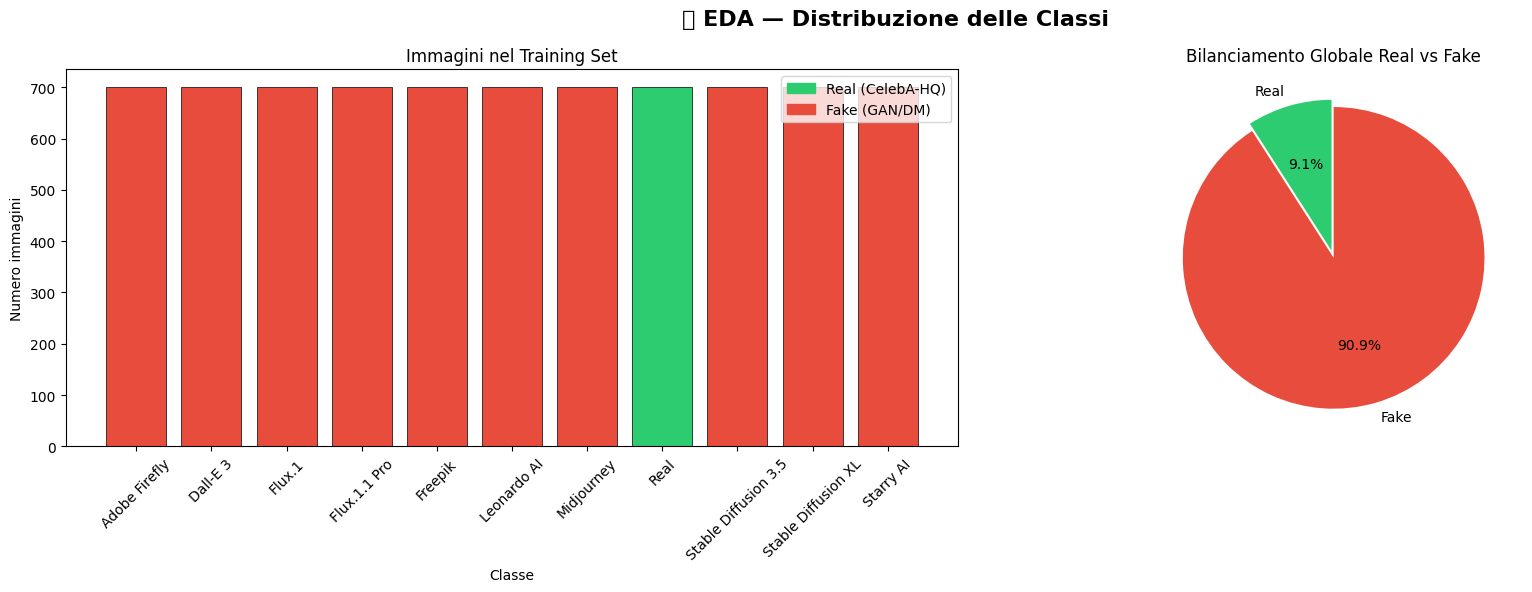


🔍 Analisi dimensioni immagini (campione 50 per classe)...


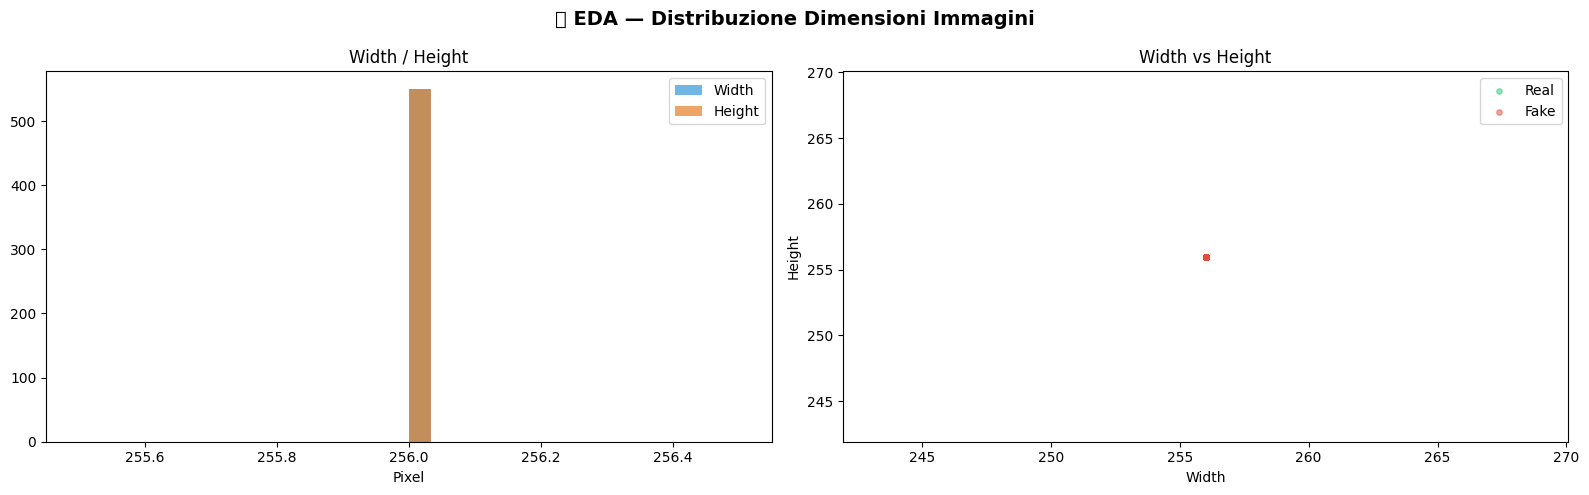


🎨 Analisi canali RGB (campione 30 per classe)...


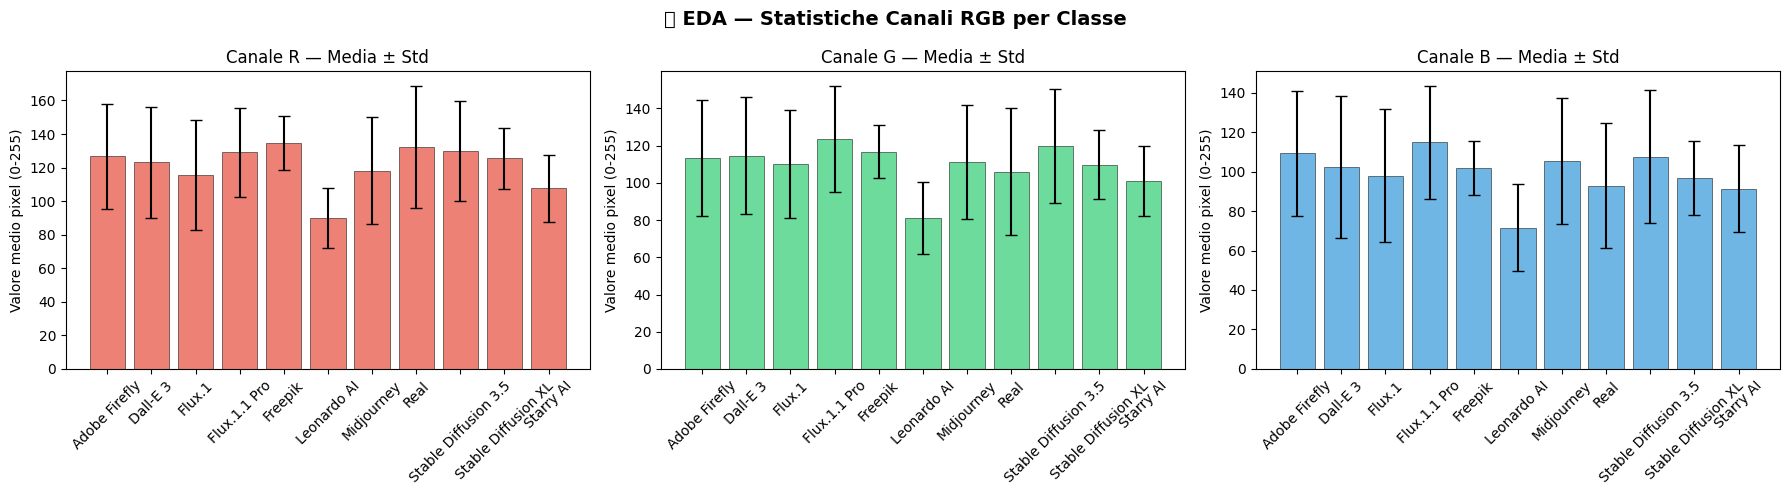


🖼️  Griglia immagini campione...


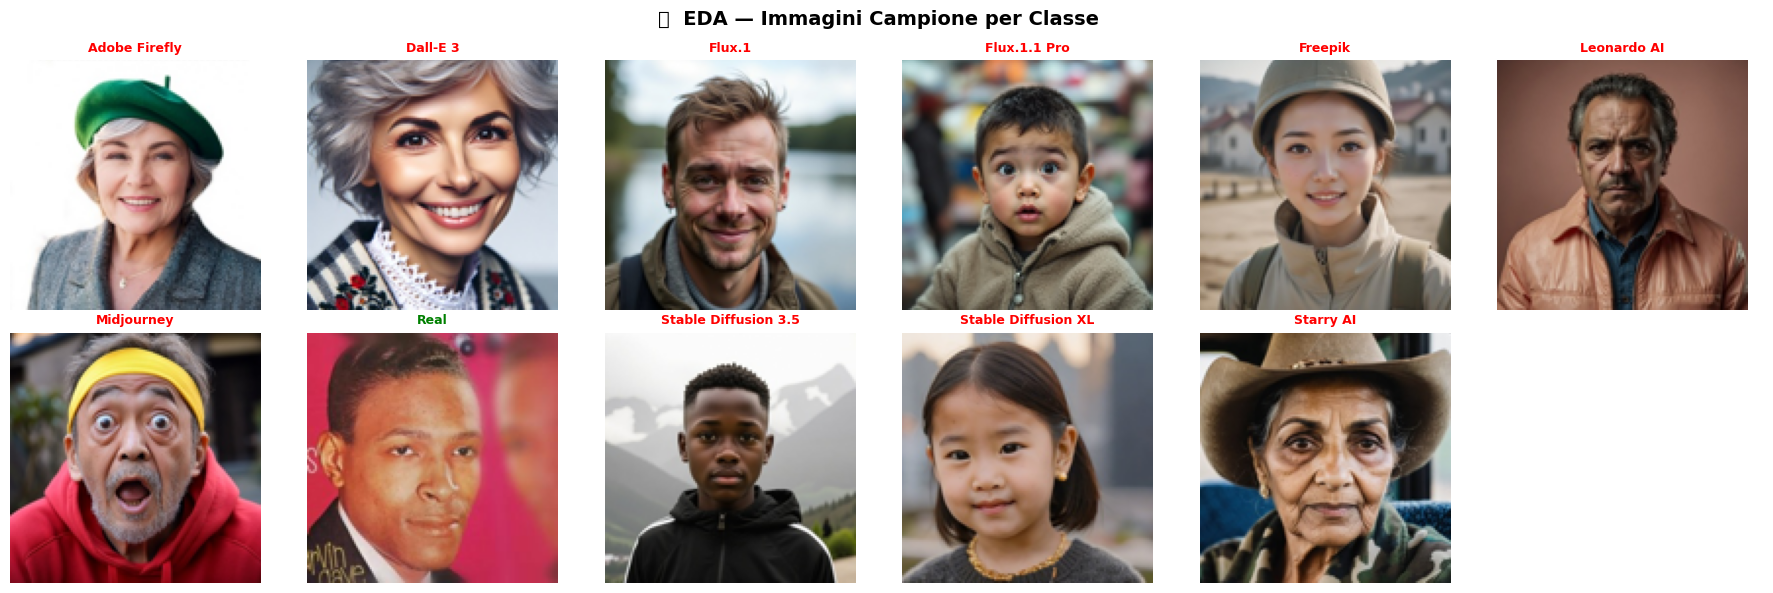


✅ EDA completata!


In [12]:
# Cella 3) EDA
def conta_immagini_per_classe(base_dir):
    return {
        cls: len(trova_immagini(os.path.join(base_dir, cls)))
        for cls in sorted(os.listdir(base_dir))
        if os.path.isdir(os.path.join(base_dir, cls))
    }

train_counts = conta_immagini_per_classe(TRAIN_DIR)
val_counts   = conta_immagini_per_classe(VAL_DIR)
test_counts  = conta_immagini_per_classe(TEST_DIR)
classi       = list(train_counts.keys())
NUM_CLASSES  = len(classi)

print(f'📊 Classi totali: {NUM_CLASSES}  (Real: 1 | Fake: {NUM_CLASSES - 1})')
df_dist = pd.DataFrame({'Train': train_counts, 'Val': val_counts, 'Test': test_counts})
df_dist['Totale'] = df_dist.sum(axis=1)
print('\n', df_dist.to_string())

# ── EDA 1: Distribuzione classi ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('📊 EDA — Distribuzione delle Classi', fontsize=16, fontweight='bold')

colori = ['#2ecc71' if c == 'Real' else '#e74c3c' for c in classi]
axes[0].bar(classi, df_dist['Train'], color=colori, edgecolor='black', linewidth=0.5)
axes[0].set_title('Immagini nel Training Set')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Numero immagini')
axes[0].tick_params(axis='x', rotation=45)
real_patch = mpatches.Patch(color='#2ecc71', label='Real (CelebA-HQ)')
fake_patch = mpatches.Patch(color='#e74c3c', label='Fake (GAN/DM)')
axes[0].legend(handles=[real_patch, fake_patch])

n_real_tot = df_dist.loc['Real', 'Totale'] if 'Real' in df_dist.index else 0
n_fake_tot = df_dist['Totale'].sum() - n_real_tot
axes[1].pie([n_real_tot, n_fake_tot],
            labels=['Real', 'Fake'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
axes[1].set_title('Bilanciamento Globale Real vs Fake')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/eda_distribuzione.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EDA 2: Dimensioni immagini ────────────────────────────────────────────────
print('\n🔍 Analisi dimensioni immagini (campione 50 per classe)...')
width_list, height_list, label_list = [], [], []

for cls in classi:
    imgs = trova_immagini(os.path.join(TRAIN_DIR, cls))
    for p in random.sample(imgs, min(50, len(imgs))):
        try:
            with Image.open(p) as img:
                w, h = img.size
                width_list.append(w)
                height_list.append(h)
                label_list.append(cls)
        except Exception:
            pass

df_dims = pd.DataFrame({'width': width_list, 'height': height_list, 'classe': label_list})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📐 EDA — Distribuzione Dimensioni Immagini', fontsize=14, fontweight='bold')
axes[0].hist(df_dims['width'],  bins=30, color='#3498db', alpha=0.7, label='Width')
axes[0].hist(df_dims['height'], bins=30, color='#e67e22', alpha=0.7, label='Height')
axes[0].set_title('Width / Height')
axes[0].set_xlabel('Pixel')
axes[0].legend()

real_mask = df_dims['classe'] == 'Real'
axes[1].scatter(df_dims.loc[real_mask,  'width'], df_dims.loc[real_mask,  'height'],
                c='#2ecc71', alpha=0.5, label='Real', s=15)
axes[1].scatter(df_dims.loc[~real_mask, 'width'], df_dims.loc[~real_mask, 'height'],
                c='#e74c3c', alpha=0.5, label='Fake', s=15)
axes[1].set_title('Width vs Height')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/eda_dimensioni.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EDA 3: Statistiche RGB ────────────────────────────────────────────────────
print('\n🎨 Analisi canali RGB (campione 30 per classe)...')
rgb_stats = []

for cls in classi:
    imgs = trova_immagini(os.path.join(TRAIN_DIR, cls))
    r_vals, g_vals, b_vals = [], [], []
    for p in random.sample(imgs, min(30, len(imgs))):
        try:
            arr = np.array(Image.open(p).convert('RGB').resize((64, 64))).astype(float)
            r_vals.append(arr[:, :, 0].mean())
            g_vals.append(arr[:, :, 1].mean())
            b_vals.append(arr[:, :, 2].mean())
        except Exception:
            pass
    rgb_stats.append({
        'classe': cls,
        'R': np.mean(r_vals), 'G': np.mean(g_vals), 'B': np.mean(b_vals),
        'R_std': np.std(r_vals), 'G_std': np.std(g_vals), 'B_std': np.std(b_vals)
    })

df_rgb = pd.DataFrame(rgb_stats).set_index('classe')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🎨 EDA — Statistiche Canali RGB per Classe', fontsize=14, fontweight='bold')
for ax, canale, colore in zip(axes, ['R', 'G', 'B'], ['#e74c3c', '#2ecc71', '#3498db']):
    ax.bar(df_rgb.index, df_rgb[canale], yerr=df_rgb[f'{canale}_std'],
           color=colore, alpha=0.7, capsize=4, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Canale {canale} — Media ± Std')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Valore medio pixel (0-255)')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/eda_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EDA 4: Griglia immagini campione ──────────────────────────────────────────
print('\n🖼️  Griglia immagini campione...')
n_cols    = min(NUM_CLASSES, 6)
n_rows    = (NUM_CLASSES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
fig.suptitle('🖼️  EDA — Immagini Campione per Classe', fontsize=14, fontweight='bold')
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, cls in enumerate(classi):
    imgs = trova_immagini(os.path.join(TRAIN_DIR, cls))
    if imgs:
        try:
            img = Image.open(random.choice(imgs)).convert('RGB').resize((128, 128))
            axes_flat[idx].imshow(img)
            colore_titolo = 'green' if cls == 'Real' else 'red'
            axes_flat[idx].set_title(cls[:20], fontsize=9,
                                     color=colore_titolo, fontweight='bold')
        except Exception:
            axes_flat[idx].text(0.5, 0.5, 'N/A', ha='center', va='center')
    axes_flat[idx].axis('off')

for idx in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/eda_griglia.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ EDA completata!')

In [13]:
# Cella 4) Data Loader & Trasformazioni
IMG_SIZE           = 224
IMG_SIZE_INCEPTION = 299
MEAN               = [0.485, 0.456, 0.406]
STD                = [0.229, 0.224, 0.225]

# Immagini già 256x256 su disco → RandomCrop diretto, nessun Resize costoso
train_transforms = transforms.Compose([
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))
])

val_test_transforms = transforms.Compose([
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Inception: 256 → resize 331 → crop 299
train_transforms_inception = transforms.Compose([
    transforms.Resize(331),
    transforms.RandomCrop(IMG_SIZE_INCEPTION),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_test_transforms_inception = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(IMG_SIZE_INCEPTION),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])


def make_loaders(is_inception=False):
    tr = train_transforms_inception    if is_inception else train_transforms
    vt = val_test_transforms_inception if is_inception else val_test_transforms

    train_ds = datasets.ImageFolder(TRAIN_DIR, transform=tr)
    val_ds   = datasets.ImageFolder(VAL_DIR,   transform=vt)
    test_ds  = datasets.ImageFolder(TEST_DIR,  transform=vt)

    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
              pin_memory=True, persistent_workers=True)
    return (DataLoader(train_ds, shuffle=True,  **kw),
            DataLoader(val_ds,   shuffle=False, **kw),
            DataLoader(test_ds,  shuffle=False, **kw),
            train_ds.classes)


train_loader,     val_loader,     test_loader,     CLASS_NAMES = make_loaders(False)
train_loader_inc, val_loader_inc, test_loader_inc, _           = make_loaders(True)

print('✅ DataLoaders pronti')
print(f'   Classi ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'   Train : {len(train_loader.dataset)} img  |  '
      f'Val: {len(val_loader.dataset)} img  |  '
      f'Test: {len(test_loader.dataset)} img')

✅ DataLoaders pronti
   Classi (11): ['Adobe Firefly', 'Dall-E 3', 'Flux.1', 'Flux.1.1 Pro', 'Freepik', 'Leonardo AI', 'Midjourney', 'Real', 'Stable Diffusion 3.5', 'Stable Diffusion XL', 'Starry AI']
   Train : 7700 img  |  Val: 1650 img  |  Test: 1650 img


In [14]:
# Cella 5) Definizione Modelli
def build_model(nome_modello, num_classes, use_parallel=True):
    is_inception = False

    if nome_modello == 'ResNet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.fc.in_features, num_classes)
        )

    elif nome_modello == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.classifier.in_features, num_classes)
        )

    elif nome_modello == 'VGG16':
        model = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT)
        in_f  = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_f, num_classes)
        )

    elif nome_modello == 'InceptionV3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.fc.in_features, num_classes)
        )
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        is_inception = True

    elif nome_modello == 'MobileNetV3':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        in_f  = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_f, num_classes)
        )

    elif nome_modello == 'ViT':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.heads.head.in_features, num_classes)
        )

    else:
        raise ValueError(f'Modello sconosciuto: {nome_modello}')

    # ── Multi-GPU solo se richiesto ───────────────────────────────────────────
    if use_parallel and num_gpus > 1:
        print(f'   🖥️  DataParallel attivo su {num_gpus} GPU')
        model = nn.DataParallel(model)

    return model.to(device), is_inception


def freeze_backbone(model, nome_modello):
    m = model.module if isinstance(model, nn.DataParallel) else model
    for param in m.parameters():
        param.requires_grad = False

    if nome_modello == 'ResNet18':
        for p in m.fc.parameters():              p.requires_grad = True
    elif nome_modello == 'DenseNet121':
        for p in m.classifier.parameters():      p.requires_grad = True
    elif nome_modello == 'VGG16':
        for p in m.classifier.parameters():      p.requires_grad = True
    elif nome_modello == 'InceptionV3':
        for p in m.fc.parameters():              p.requires_grad = True
        for p in m.AuxLogits.fc.parameters():    p.requires_grad = True
    elif nome_modello == 'MobileNetV3':
        for p in m.classifier.parameters():      p.requires_grad = True
    elif nome_modello == 'ViT':
        for p in m.heads.parameters():           p.requires_grad = True


def unfreeze_all(model):
    m = model.module if isinstance(model, nn.DataParallel) else model
    for param in m.parameters():
        param.requires_grad = True


print('✅ Factory modelli pronta.')
print('   Modelli: ResNet18 | DenseNet121 | VGG16 | InceptionV3 | MobileNetV3 | ViT')

✅ Factory modelli pronta.
   Modelli: ResNet18 | DenseNet121 | VGG16 | InceptionV3 | MobileNetV3 | ViT


In [8]:
# Cella 6) Training Universale
def train_one_epoch(model, loader, optimizer, criterion, scaler, is_inception):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast():
            if is_inception:
                outputs, aux = model(imgs)
                loss = criterion(outputs, labels) + 0.4 * criterion(aux, labels)
            else:
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        _, pred     = outputs.max(1)
        correct    += pred.eq(labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        _, pred     = outputs.max(1)
        correct    += pred.eq(labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(nome_modello, epochs=EPOCHS, lr=LR, freeze_epochs=3):
    print(f'\n{"="*60}')
    print(f'  🧠 Modello: {nome_modello}')
    print(f'{"="*60}')

    is_inception = (nome_modello == 'InceptionV3')
    tr_loader    = train_loader_inc if is_inception else train_loader
    vl_loader    = val_loader_inc   if is_inception else val_loader

    model, _  = build_model(nome_modello, len(CLASS_NAMES))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler    = GradScaler()

    # ── FASE 1: solo head ────────────────────────────────────────────────────
    freeze_backbone(model, nome_modello)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=freeze_epochs)

    history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc     = 0.0
    patience_counter = 0
    best_path        = f'{MODEL_DIR}/{nome_modello}_best.pth'

    for epoch in range(1, epochs + 1):

        # ── FASE 2: unfreeze dopo freeze_epochs ──────────────────────────────
        if epoch == freeze_epochs + 1:
            print(f'   🔓 Fase 2: unfreeze backbone — LR → {lr/10:.6f}')
            unfreeze_all(model)
            optimizer = optim.AdamW(model.parameters(),
                                    lr=lr / 10, weight_decay=WEIGHT_DECAY)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(epochs - freeze_epochs)
            )

        t0              = time.time()
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer,
                                          criterion, scaler, is_inception)
        vl_loss, vl_acc = evaluate(model, vl_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        elapsed = time.time() - t0
        print(f'   Ep {epoch:2d}/{epochs} [{elapsed:5.1f}s]  '
              f'Train Loss {tr_loss:.4f} Acc {tr_acc:.2f}%  |  '
              f'Val Loss {vl_loss:.4f} Acc {vl_acc:.2f}%')

        # ── EarlyStopping + Best checkpoint ──────────────────────────────────
        if vl_acc > best_val_acc:
            best_val_acc     = vl_acc
            patience_counter = 0
            # Salva senza wrapper DataParallel
            state = (model.module.state_dict()
                     if isinstance(model, nn.DataParallel)
                     else model.state_dict())
            torch.save(state, best_path)
        else:
            patience_counter += 1
            if patience_counter >= 3 and epoch > freeze_epochs:
                print(f'   ⏹  EarlyStopping a epoca {epoch} '
                      f'(best val acc: {best_val_acc:.2f}%)')
                break

    print(f'   ✅ Best Val Acc: {best_val_acc:.2f}%  →  {best_path}')
    return history, best_path, best_val_acc


print('✅ Training engine pronto.')

✅ Training engine pronto.


In [9]:
# Cella 7) Addestramento Modelli
MODELLI = ['ResNet18', 'DenseNet121', 'VGG16', 'InceptionV3', 'MobileNetV3', 'ViT']

all_histories  = {}
all_best_paths = {}
all_best_accs  = {}

for nome in MODELLI:
    torch.cuda.empty_cache()
    history, best_path, best_acc = train_model(nome, epochs=EPOCHS)
    all_histories[nome]  = history
    all_best_paths[nome] = best_path
    all_best_accs[nome]  = best_acc

print('\n' + '='*60)
print('  🏆 Training completato per tutti i modelli!')
print('='*60)
for nome, acc in all_best_accs.items():
    print(f'   {nome:<15}  best val acc: {acc:.2f}%')


  🧠 Modello: ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


   🖥️  DataParallel attivo su 2 GPU
   Ep  1/10 [ 40.2s]  Train Loss 2.2679 Acc 21.99%  |  Val Loss 1.9319 Acc 36.91%
   Ep  2/10 [ 37.8s]  Train Loss 1.9250 Acc 38.74%  |  Val Loss 1.6903 Acc 53.82%
   Ep  3/10 [ 38.3s]  Train Loss 1.8286 Acc 43.83%  |  Val Loss 1.6466 Acc 56.79%
   🔓 Fase 2: unfreeze backbone — LR → 0.000100
   Ep  4/10 [ 58.8s]  Train Loss 1.2566 Acc 69.53%  |  Val Loss 0.8476 Acc 89.88%
   Ep  5/10 [ 41.6s]  Train Loss 0.8950 Acc 87.92%  |  Val Loss 0.7679 Acc 93.39%
   Ep  6/10 [ 41.6s]  Train Loss 0.8161 Acc 91.19%  |  Val Loss 0.7108 Acc 96.06%
   Ep  7/10 [ 41.7s]  Train Loss 0.7594 Acc 94.08%  |  Val Loss 0.6946 Acc 96.06%
   Ep  8/10 [ 41.7s]  Train Loss 0.7335 Acc 94.92%  |  Val Loss 0.6795 Acc 96.85%
   Ep  9/10 [ 41.6s]  Train Loss 0.7164 Acc 95.34%  |  Val Loss 0.6633 Acc 97.52%
   Ep 10/10 [ 41.7s]  Train Loss 0.7045 Acc 95.96%  |  Val Loss 0.6612 Acc 97.58%
   ✅ Best Val Acc: 97.58%  →  /kaggle/working/deepfake_v2/models/ResNet18_best.pth

  🧠 Modello: 

100%|██████████| 30.8M/30.8M [00:00<00:00, 186MB/s]


   🖥️  DataParallel attivo su 2 GPU
   Ep  1/10 [100.2s]  Train Loss 2.2005 Acc 25.14%  |  Val Loss 1.8362 Acc 50.85%
   Ep  2/10 [100.0s]  Train Loss 1.8189 Acc 46.05%  |  Val Loss 1.6485 Acc 58.79%
   Ep  3/10 [ 99.8s]  Train Loss 1.7064 Acc 51.34%  |  Val Loss 1.5827 Acc 62.67%
   🔓 Fase 2: unfreeze backbone — LR → 0.000100
   Ep  4/10 [148.0s]  Train Loss 1.1976 Acc 74.27%  |  Val Loss 0.8181 Acc 91.70%
   Ep  5/10 [125.4s]  Train Loss 0.8326 Acc 90.34%  |  Val Loss 0.7027 Acc 95.58%
   Ep  6/10 [125.2s]  Train Loss 0.7428 Acc 93.97%  |  Val Loss 0.6478 Acc 97.52%
   Ep  7/10 [124.6s]  Train Loss 0.6934 Acc 96.08%  |  Val Loss 0.6215 Acc 98.12%
   Ep  8/10 [125.3s]  Train Loss 0.6695 Acc 96.77%  |  Val Loss 0.6102 Acc 98.24%
   Ep  9/10 [125.2s]  Train Loss 0.6565 Acc 97.21%  |  Val Loss 0.6070 Acc 98.30%
   Ep 10/10 [125.4s]  Train Loss 0.6474 Acc 97.66%  |  Val Loss 0.6021 Acc 98.61%
   ✅ Best Val Acc: 98.61%  →  /kaggle/working/deepfake_v2/models/DenseNet121_best.pth

  🧠 Modell

...

   🖥️  DataParallel attivo su 2 GPU
   Ep  1/10 [114.0s]  Train Loss 2.9224 Acc 25.70%  |  Val Loss 1.9533 Acc 46.73%
   Ep  2/10 [111.6s]  Train Loss 2.4411 Acc 42.30%  |  Val Loss 1.8182 Acc 50.79%
   Ep  3/10 [111.5s]  Train Loss 2.3098 Acc 47.36%  |  Val Loss 1.7552 Acc 54.67%
   🔓 Fase 2: unfreeze backbone — LR → 0.000100
   Ep  4/10 [165.9s]  Train Loss 1.4630 Acc 77.75%  |  Val Loss 0.7544 Acc 91.70%
   Ep  5/10 [137.8s]  Train Loss 0.9796 Acc 94.78%  |  Val Loss 0.7129 Acc 92.55%
   Ep  6/10 [137.9s]  Train Loss 0.8719 Acc 97.87%  |  Val Loss 0.6362 Acc 96.18%
   Ep  7/10 [138.0s]  Train Loss 0.8280 Acc 98.65%  |  Val Loss 0.6267 Acc 95.76%
   Ep  8/10 [137.8s]  Train Loss 0.8011 Acc 99.23%  |  Val Loss 0.6061 Acc 96.06%
   Ep  9/10 [137.5s]  Train Loss 0.7873 Acc 99.48%  |  Val Loss 0.5942 Acc 96.67%
   Ep 10/10 [138.3s]  Train Loss 0.7813 Acc 99.62%  |  Val Loss 0.5797 Acc 97.33%
   ✅ Best Val Acc: 97.33%  →  /kaggle/working/deepfake_v2/models/InceptionV3_best.pth

  🧠 Modell

100%|██████████| 21.1M/21.1M [00:00<00:00, 176MB/s]


   🖥️  DataParallel attivo su 2 GPU
   Ep  1/10 [343.6s]  Train Loss 1.6409 Acc 53.56%  |  Val Loss 1.6931 Acc 49.82%
   Ep  2/10 [343.1s]  Train Loss 1.2367 Acc 70.62%  |  Val Loss 1.3275 Acc 66.97%
   Ep  3/10 [344.5s]  Train Loss 1.1574 Acc 75.00%  |  Val Loss 1.1202 Acc 76.55%
   🔓 Fase 2: unfreeze backbone — LR → 0.000100
   Ep  4/10 [433.2s]  Train Loss 1.0080 Acc 82.36%  |  Val Loss 0.8935 Acc 87.03%
   Ep  5/10 [355.2s]  Train Loss 0.8404 Acc 91.03%  |  Val Loss 0.7884 Acc 92.12%
   Ep  6/10 [353.1s]  Train Loss 0.7716 Acc 93.73%  |  Val Loss 0.7339 Acc 95.03%
   Ep  7/10 [352.8s]  Train Loss 0.7290 Acc 95.60%  |  Val Loss 0.7121 Acc 95.39%
   Ep  8/10 [351.8s]  Train Loss 0.7016 Acc 96.55%  |  Val Loss 0.6981 Acc 96.18%
   Ep  9/10 [352.8s]  Train Loss 0.6920 Acc 96.90%  |  Val Loss 0.6820 Acc 96.67%
   Ep 10/10 [354.0s]  Train Loss 0.6844 Acc 97.27%  |  Val Loss 0.6806 Acc 96.79%
   ✅ Best Val Acc: 96.79%  →  /kaggle/working/deepfake_v2/models/MobileNetV3_best.pth

  🧠 Modell

100%|██████████| 330M/330M [00:01<00:00, 234MB/s] 


   🖥️  DataParallel attivo su 2 GPU
   Ep  1/10 [ 37.6s]  Train Loss 2.0207 Acc 34.66%  |  Val Loss 1.6382 Acc 55.88%
   Ep  2/10 [ 37.8s]  Train Loss 1.6636 Acc 52.17%  |  Val Loss 1.4646 Acc 65.15%
   Ep  3/10 [ 37.9s]  Train Loss 1.5560 Acc 57.79%  |  Val Loss 1.4271 Acc 66.73%
   🔓 Fase 2: unfreeze backbone — LR → 0.000100
   Ep  4/10 [ 77.0s]  Train Loss 1.0836 Acc 78.48%  |  Val Loss 0.7768 Acc 93.39%
   Ep  5/10 [ 77.1s]  Train Loss 0.7537 Acc 93.30%  |  Val Loss 0.6589 Acc 96.85%
   Ep  6/10 [ 76.9s]  Train Loss 0.6636 Acc 96.62%  |  Val Loss 0.6306 Acc 97.21%
   Ep  7/10 [ 77.2s]  Train Loss 0.6108 Acc 97.83%  |  Val Loss 0.6109 Acc 97.39%
   Ep  8/10 [ 77.2s]  Train Loss 0.5777 Acc 98.94%  |  Val Loss 0.5783 Acc 98.42%
   Ep  9/10 [ 77.0s]  Train Loss 0.5534 Acc 99.49%  |  Val Loss 0.5740 Acc 97.94%
   Ep 10/10 [ 77.2s]  Train Loss 0.5472 Acc 99.51%  |  Val Loss 0.5576 Acc 98.48%
   ✅ Best Val Acc: 98.48%  →  /kaggle/working/deepfake_v2/models/ViT_best.pth

  🏆 Training compl

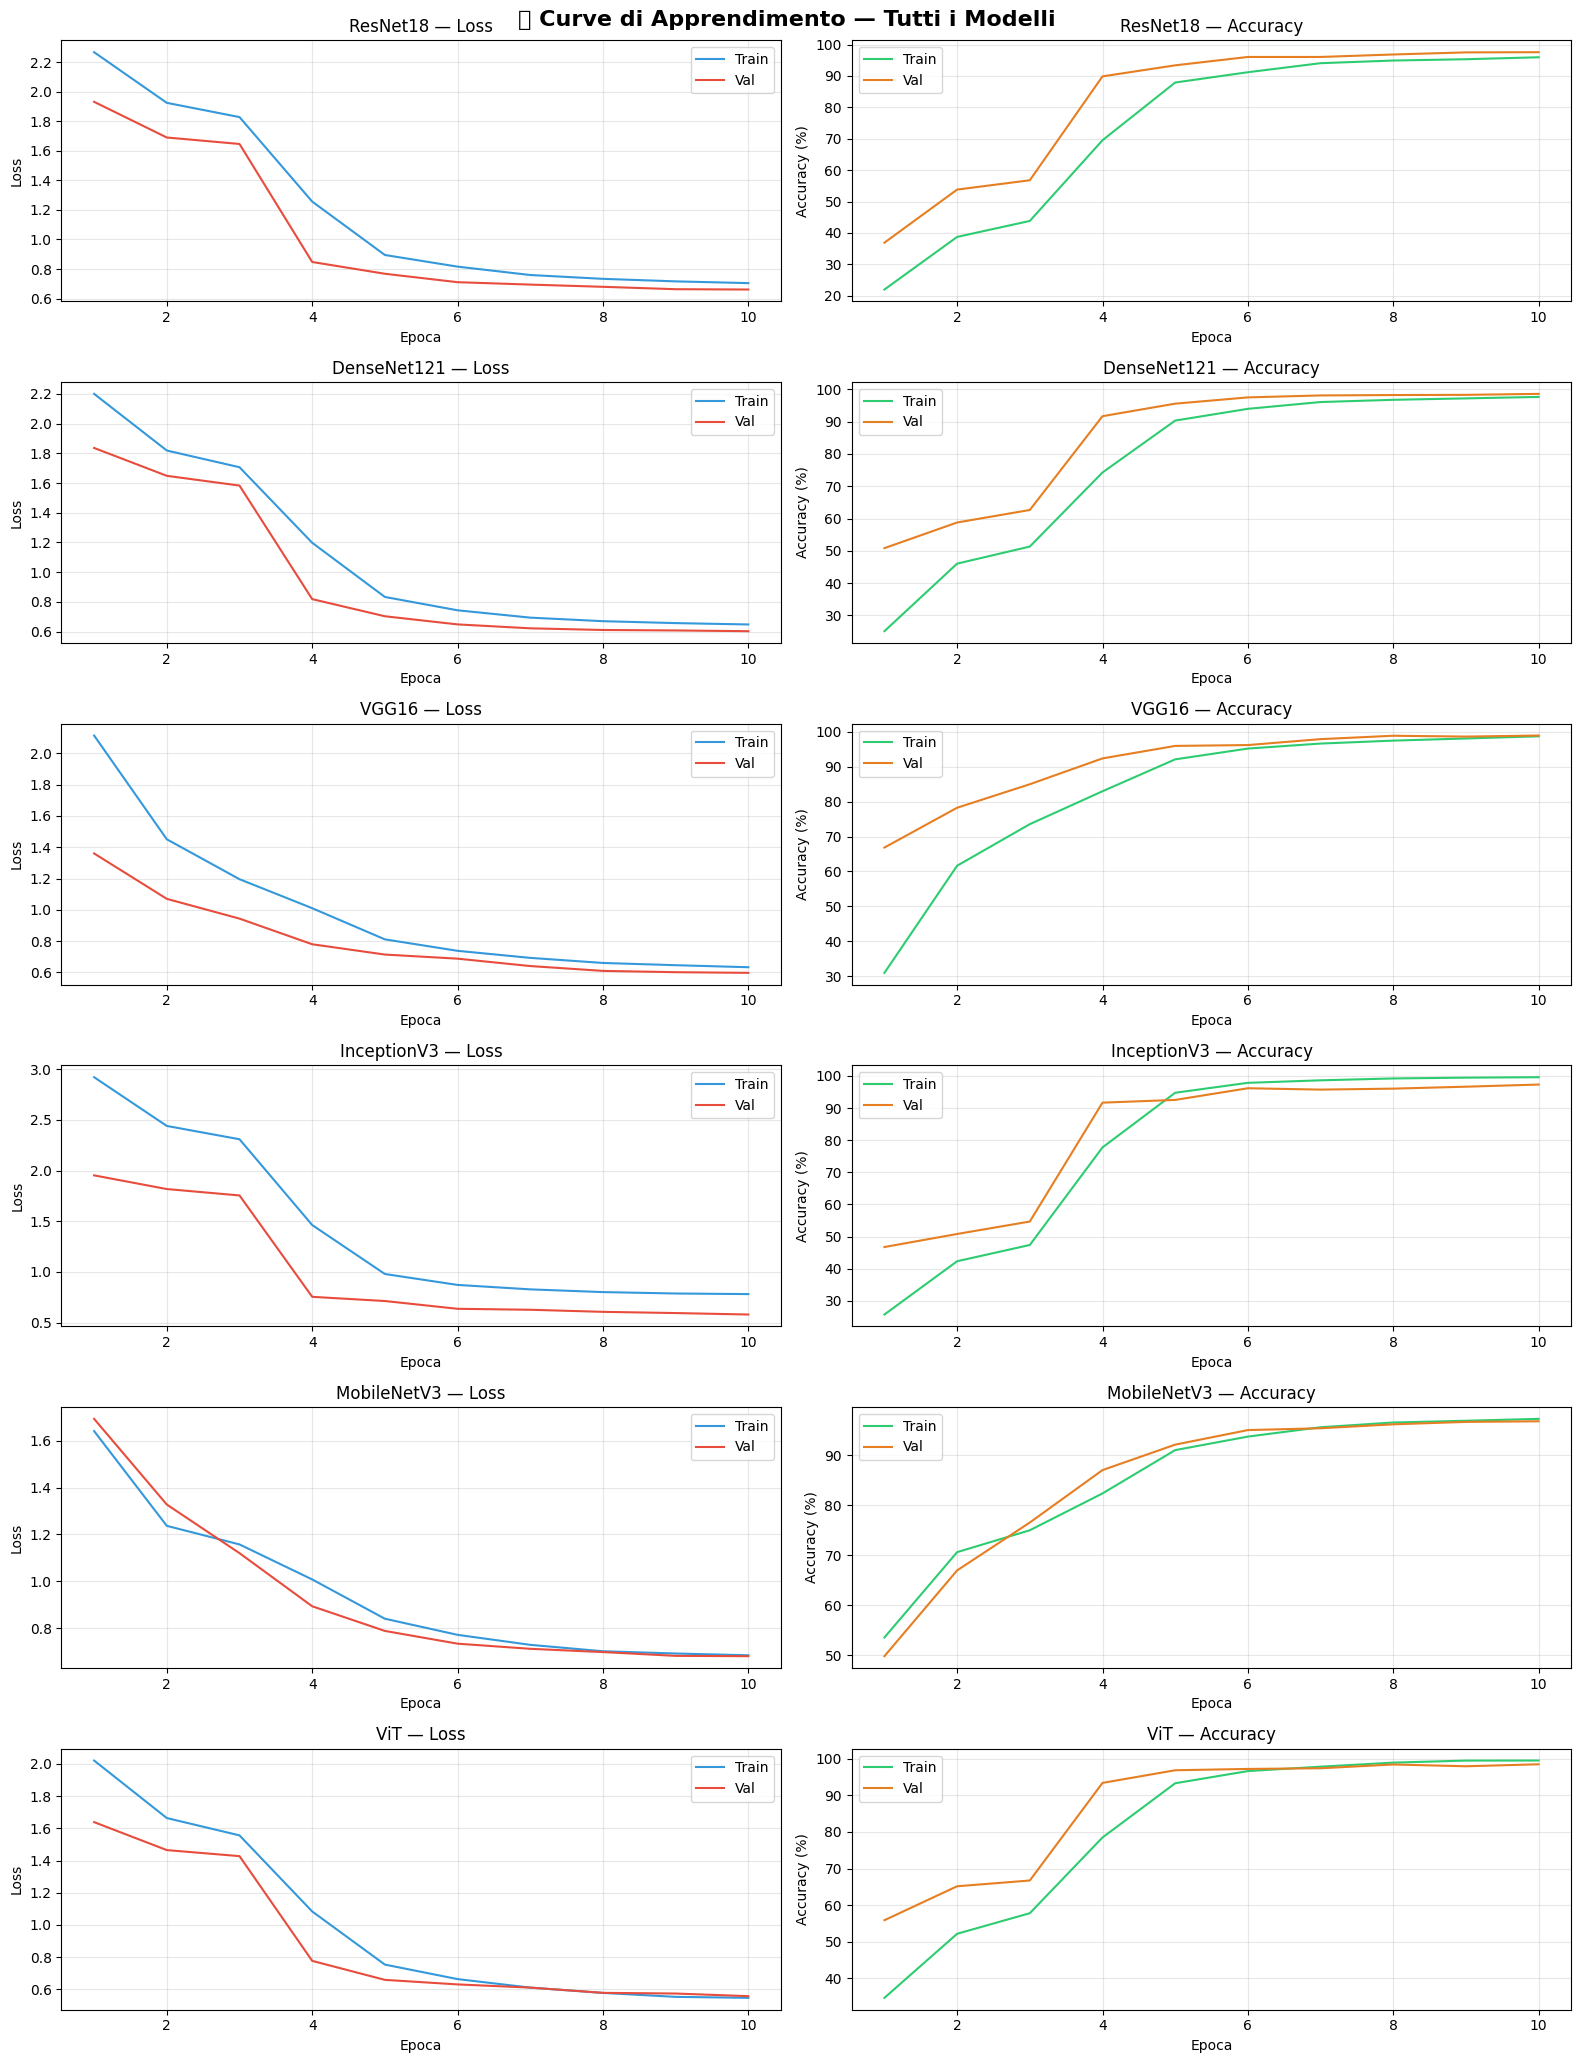

✅ Curve di apprendimento salvate.


In [10]:
# Cella 8) Curve di apprendimento
fig, axes = plt.subplots(len(MODELLI), 2, figsize=(16, len(MODELLI) * 3.5))
fig.suptitle('📈 Curve di Apprendimento — Tutti i Modelli',
             fontsize=16, fontweight='bold')

for i, nome in enumerate(MODELLI):
    h  = all_histories[nome]
    ep = range(1, len(h['train_loss']) + 1)

    axes[i, 0].plot(ep, h['train_loss'], label='Train', color='#3498db')
    axes[i, 0].plot(ep, h['val_loss'],   label='Val',   color='#e74c3c')
    axes[i, 0].set_title(f'{nome} — Loss')
    axes[i, 0].set_xlabel('Epoca')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(ep, h['train_acc'], label='Train', color='#2ecc71')
    axes[i, 1].plot(ep, h['val_acc'],   label='Val',   color='#e67e22')
    axes[i, 1].set_title(f'{nome} — Accuracy')
    axes[i, 1].set_xlabel('Epoca')
    axes[i, 1].set_ylabel('Accuracy (%)')
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curve di apprendimento salvate.')


───────────────────────────────────────────────────────
📊 Valutazione Test Set: ResNet18
───────────────────────────────────────────────────────
   Accuracy  : 97.33%
   Precision : 97.36%
   Recall    : 97.33%
   F1-Score  : 97.34%


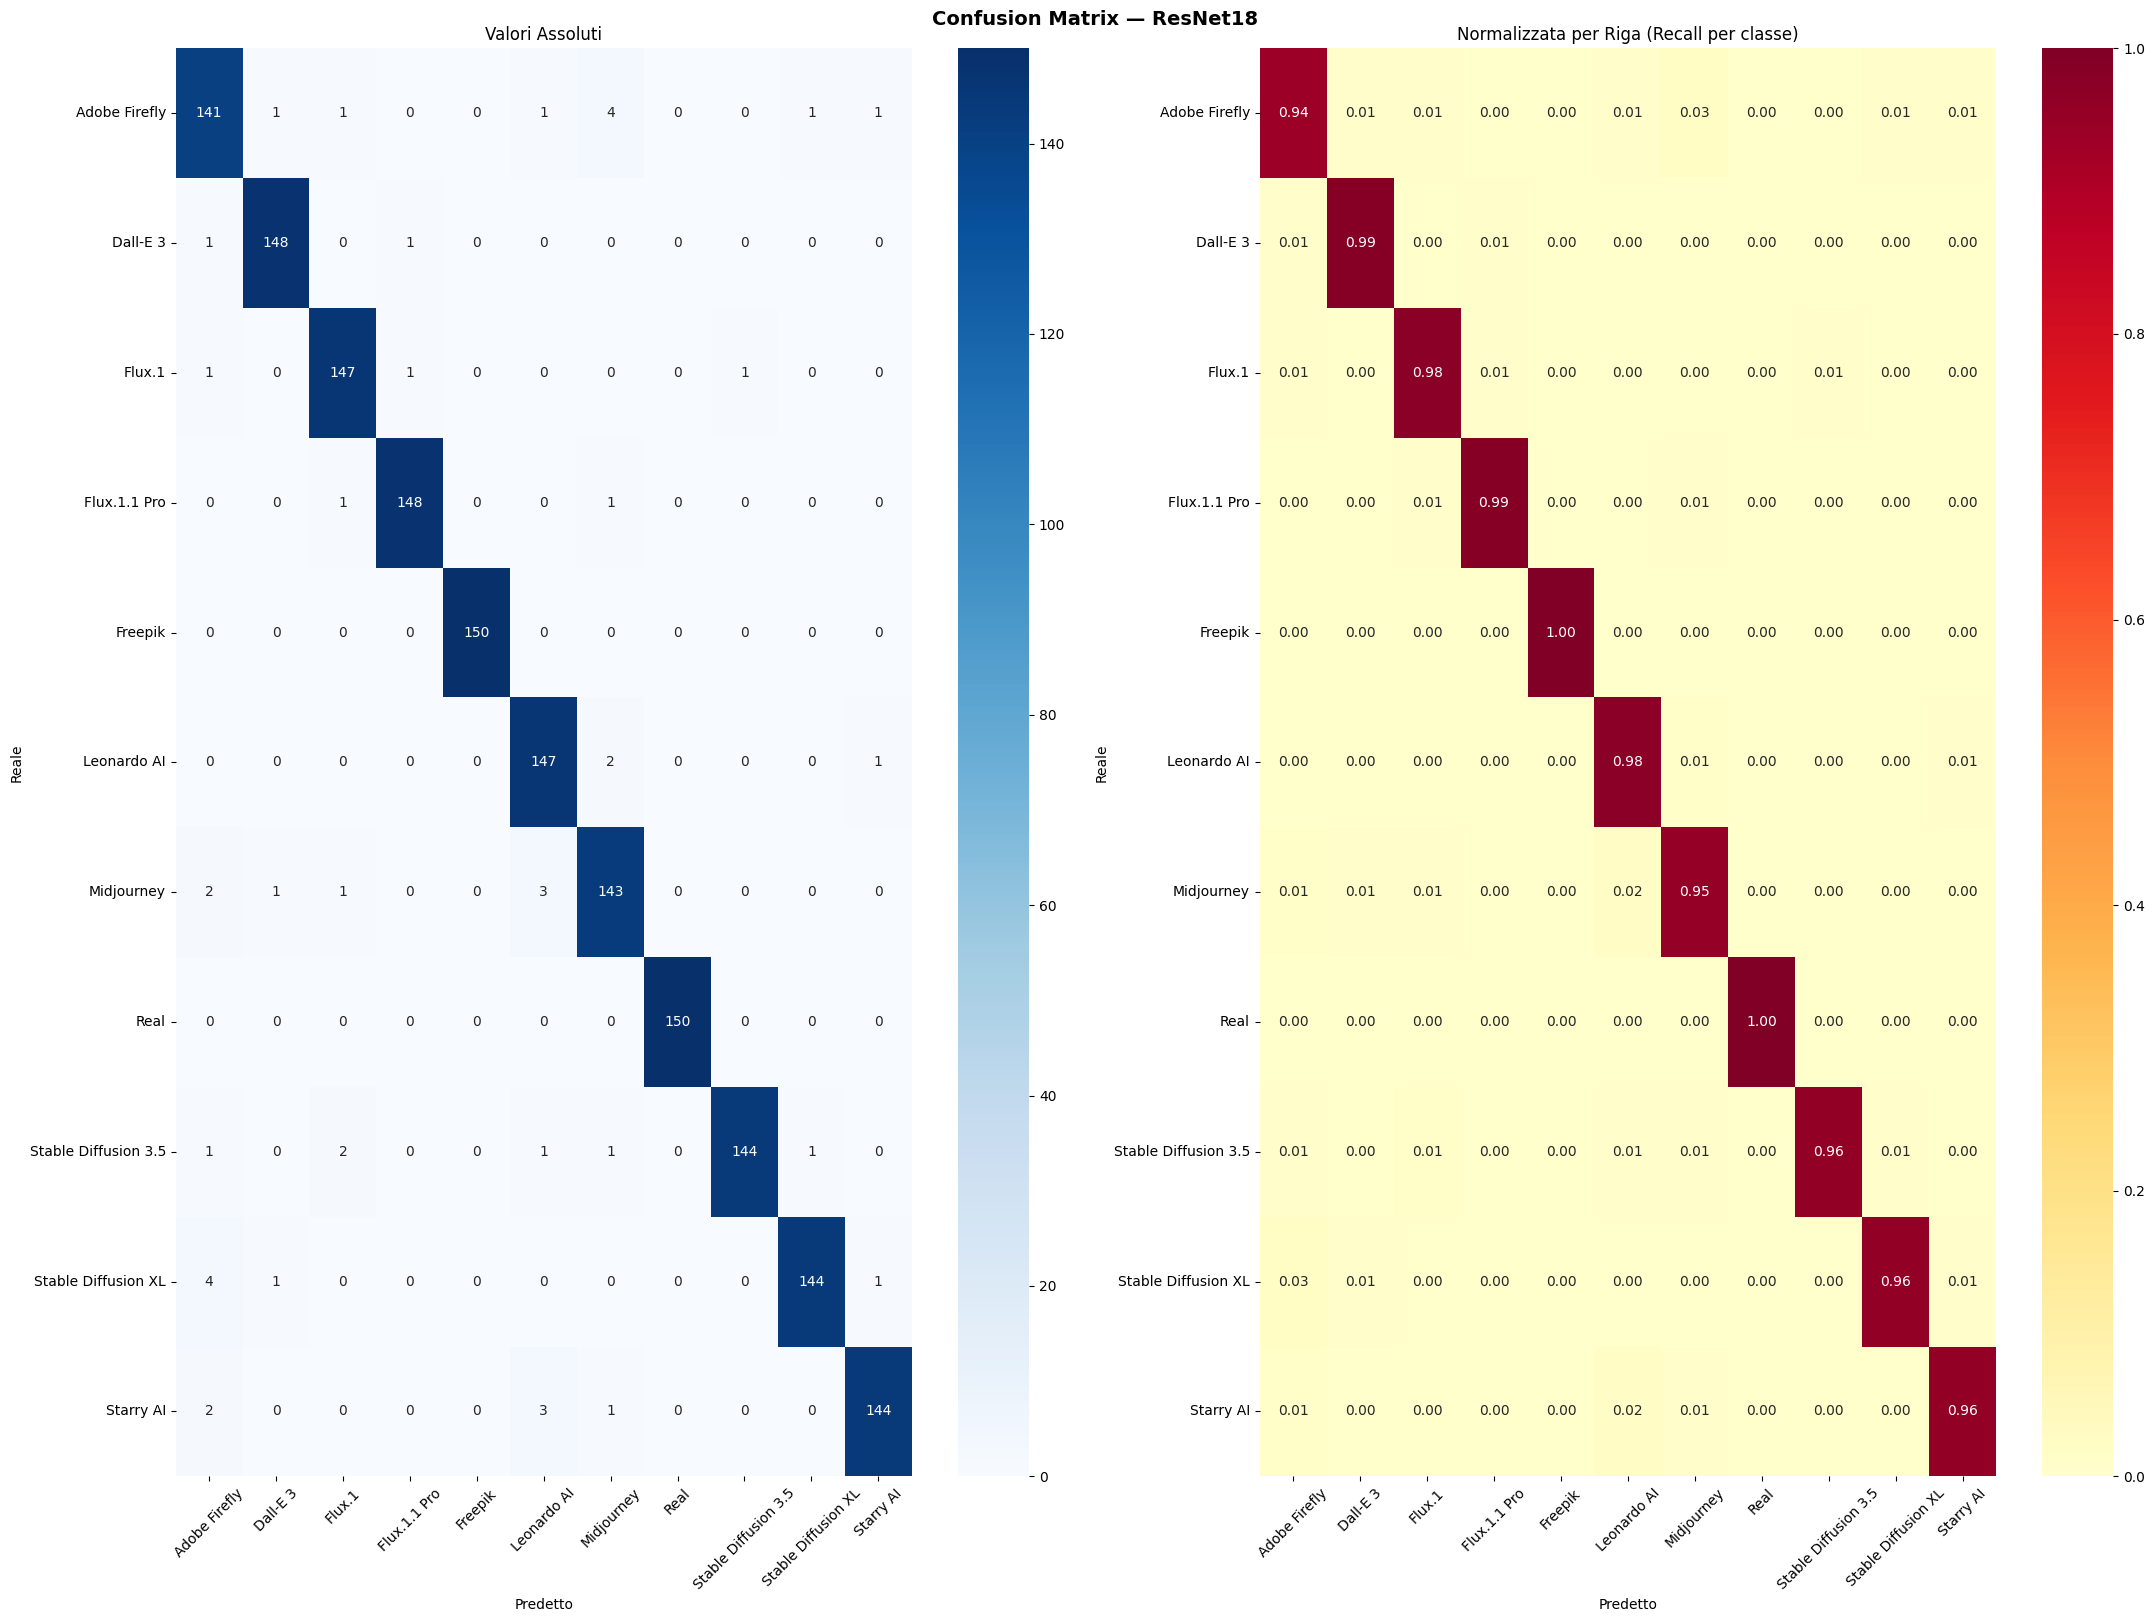


   Classification Report (ResNet18):
                      precision    recall  f1-score   support

       Adobe Firefly     0.9276    0.9400    0.9338       150
            Dall-E 3     0.9801    0.9867    0.9834       150
              Flux.1     0.9671    0.9800    0.9735       150
        Flux.1.1 Pro     0.9867    0.9867    0.9867       150
             Freepik     1.0000    1.0000    1.0000       150
         Leonardo AI     0.9484    0.9800    0.9639       150
          Midjourney     0.9408    0.9533    0.9470       150
                Real     1.0000    1.0000    1.0000       150
Stable Diffusion 3.5     0.9931    0.9600    0.9763       150
 Stable Diffusion XL     0.9863    0.9600    0.9730       150
           Starry AI     0.9796    0.9600    0.9697       150

            accuracy                         0.9733      1650
           macro avg     0.9736    0.9733    0.9734      1650
        weighted avg     0.9736    0.9733    0.9734      1650


────────────────────────────

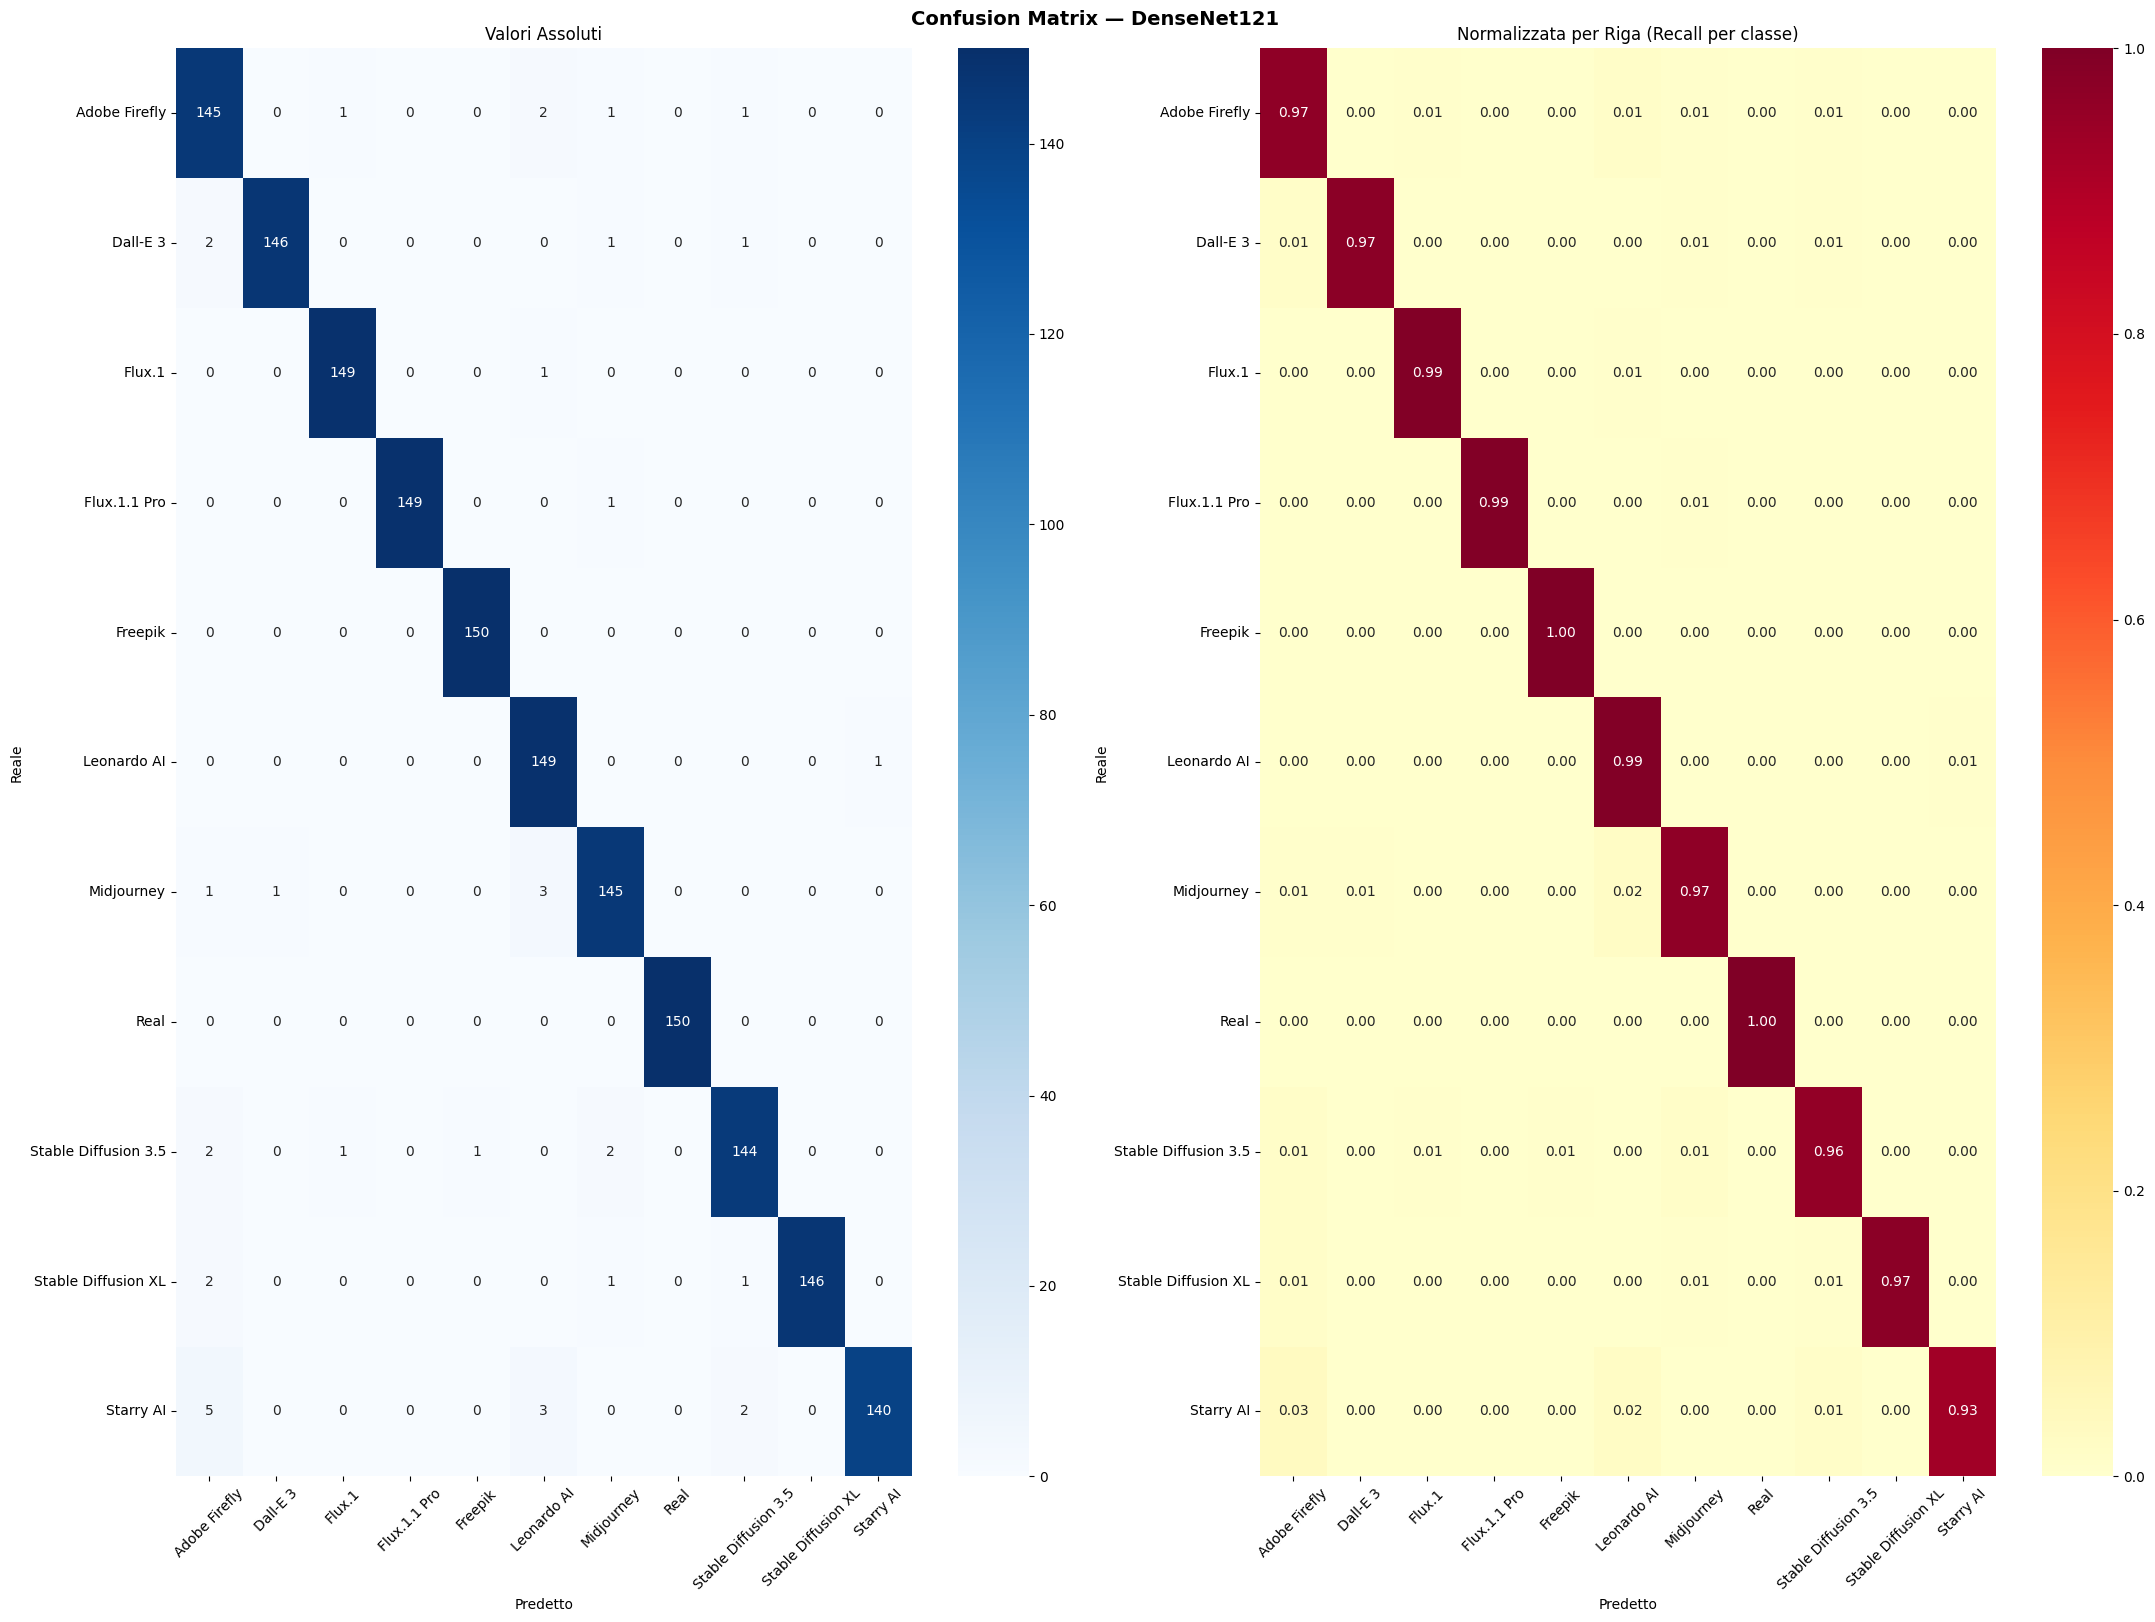


   Classification Report (DenseNet121):
                      precision    recall  f1-score   support

       Adobe Firefly     0.9236    0.9667    0.9446       150
            Dall-E 3     0.9932    0.9733    0.9832       150
              Flux.1     0.9868    0.9933    0.9900       150
        Flux.1.1 Pro     1.0000    0.9933    0.9967       150
             Freepik     0.9934    1.0000    0.9967       150
         Leonardo AI     0.9430    0.9933    0.9675       150
          Midjourney     0.9603    0.9667    0.9635       150
                Real     1.0000    1.0000    1.0000       150
Stable Diffusion 3.5     0.9664    0.9600    0.9632       150
 Stable Diffusion XL     1.0000    0.9733    0.9865       150
           Starry AI     0.9929    0.9333    0.9622       150

            accuracy                         0.9776      1650
           macro avg     0.9781    0.9776    0.9776      1650
        weighted avg     0.9781    0.9776    0.9776      1650


─────────────────────────

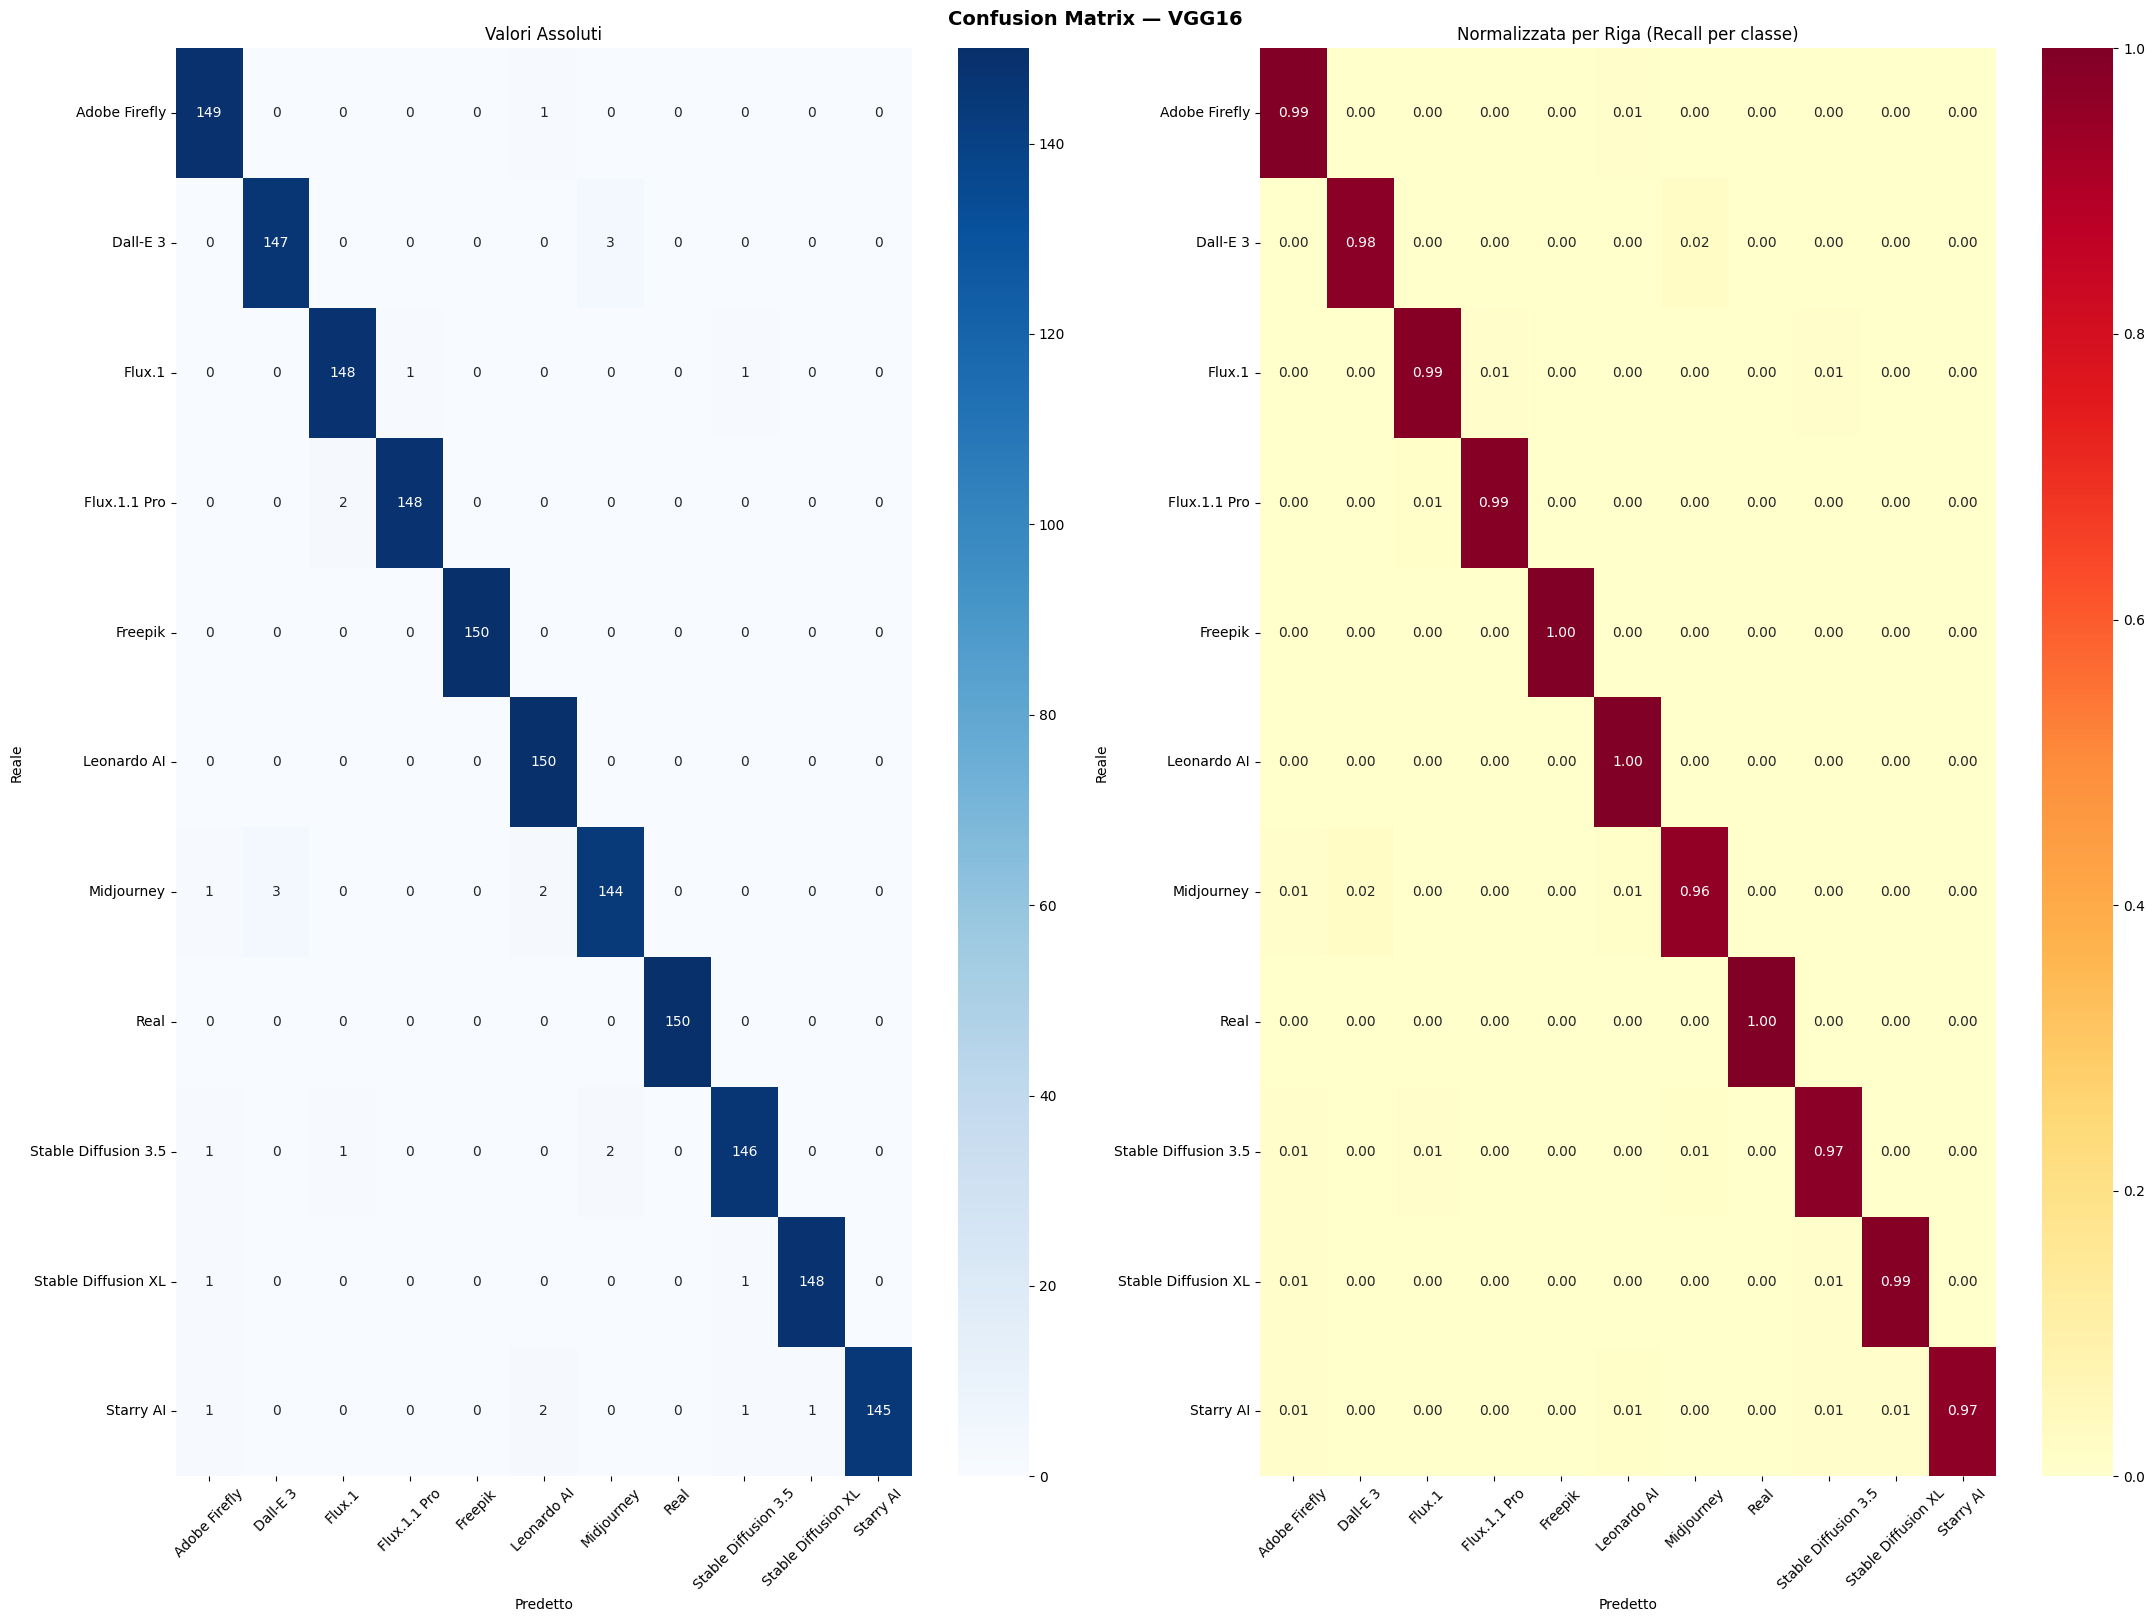


   Classification Report (VGG16):
                      precision    recall  f1-score   support

       Adobe Firefly     0.9739    0.9933    0.9835       150
            Dall-E 3     0.9800    0.9800    0.9800       150
              Flux.1     0.9801    0.9867    0.9834       150
        Flux.1.1 Pro     0.9933    0.9867    0.9900       150
             Freepik     1.0000    1.0000    1.0000       150
         Leonardo AI     0.9677    1.0000    0.9836       150
          Midjourney     0.9664    0.9600    0.9632       150
                Real     1.0000    1.0000    1.0000       150
Stable Diffusion 3.5     0.9799    0.9733    0.9766       150
 Stable Diffusion XL     0.9933    0.9867    0.9900       150
           Starry AI     1.0000    0.9667    0.9831       150

            accuracy                         0.9848      1650
           macro avg     0.9850    0.9848    0.9848      1650
        weighted avg     0.9850    0.9848    0.9848      1650


───────────────────────────────

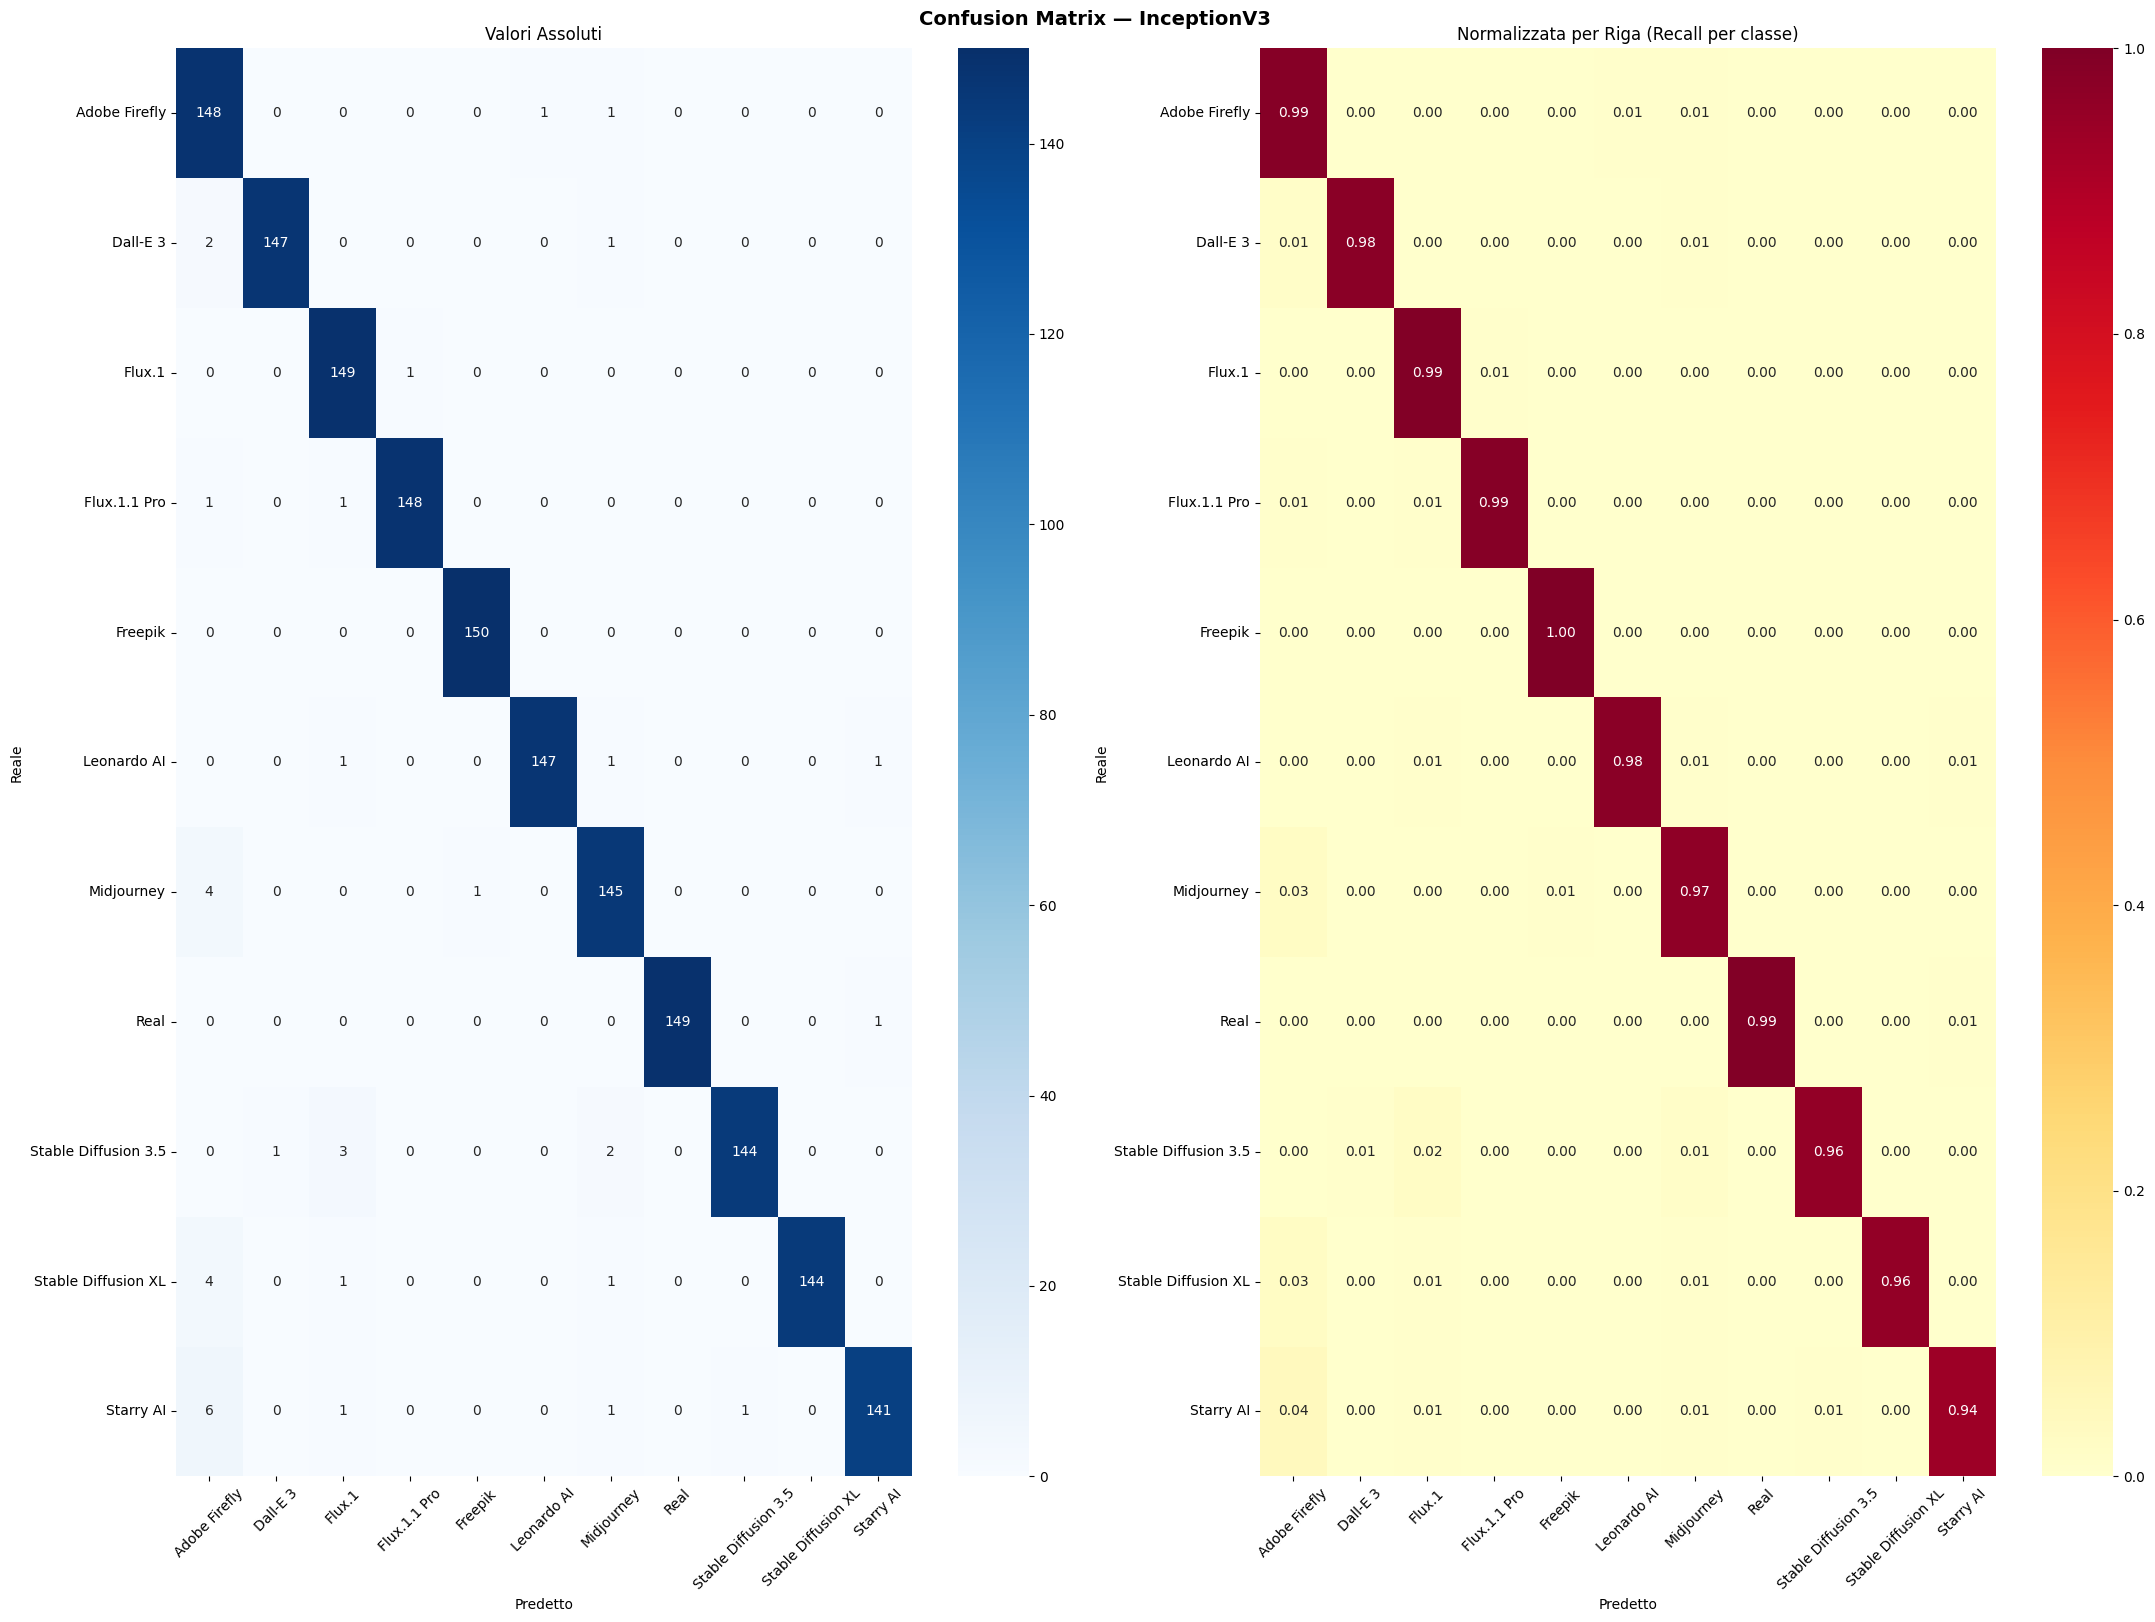


   Classification Report (InceptionV3):
                      precision    recall  f1-score   support

       Adobe Firefly     0.8970    0.9867    0.9397       150
            Dall-E 3     0.9932    0.9800    0.9866       150
              Flux.1     0.9551    0.9933    0.9739       150
        Flux.1.1 Pro     0.9933    0.9867    0.9900       150
             Freepik     0.9934    1.0000    0.9967       150
         Leonardo AI     0.9932    0.9800    0.9866       150
          Midjourney     0.9539    0.9667    0.9603       150
                Real     1.0000    0.9933    0.9967       150
Stable Diffusion 3.5     0.9931    0.9600    0.9763       150
 Stable Diffusion XL     1.0000    0.9600    0.9796       150
           Starry AI     0.9860    0.9400    0.9625       150

            accuracy                         0.9770      1650
           macro avg     0.9780    0.9770    0.9771      1650
        weighted avg     0.9780    0.9770    0.9771      1650


─────────────────────────

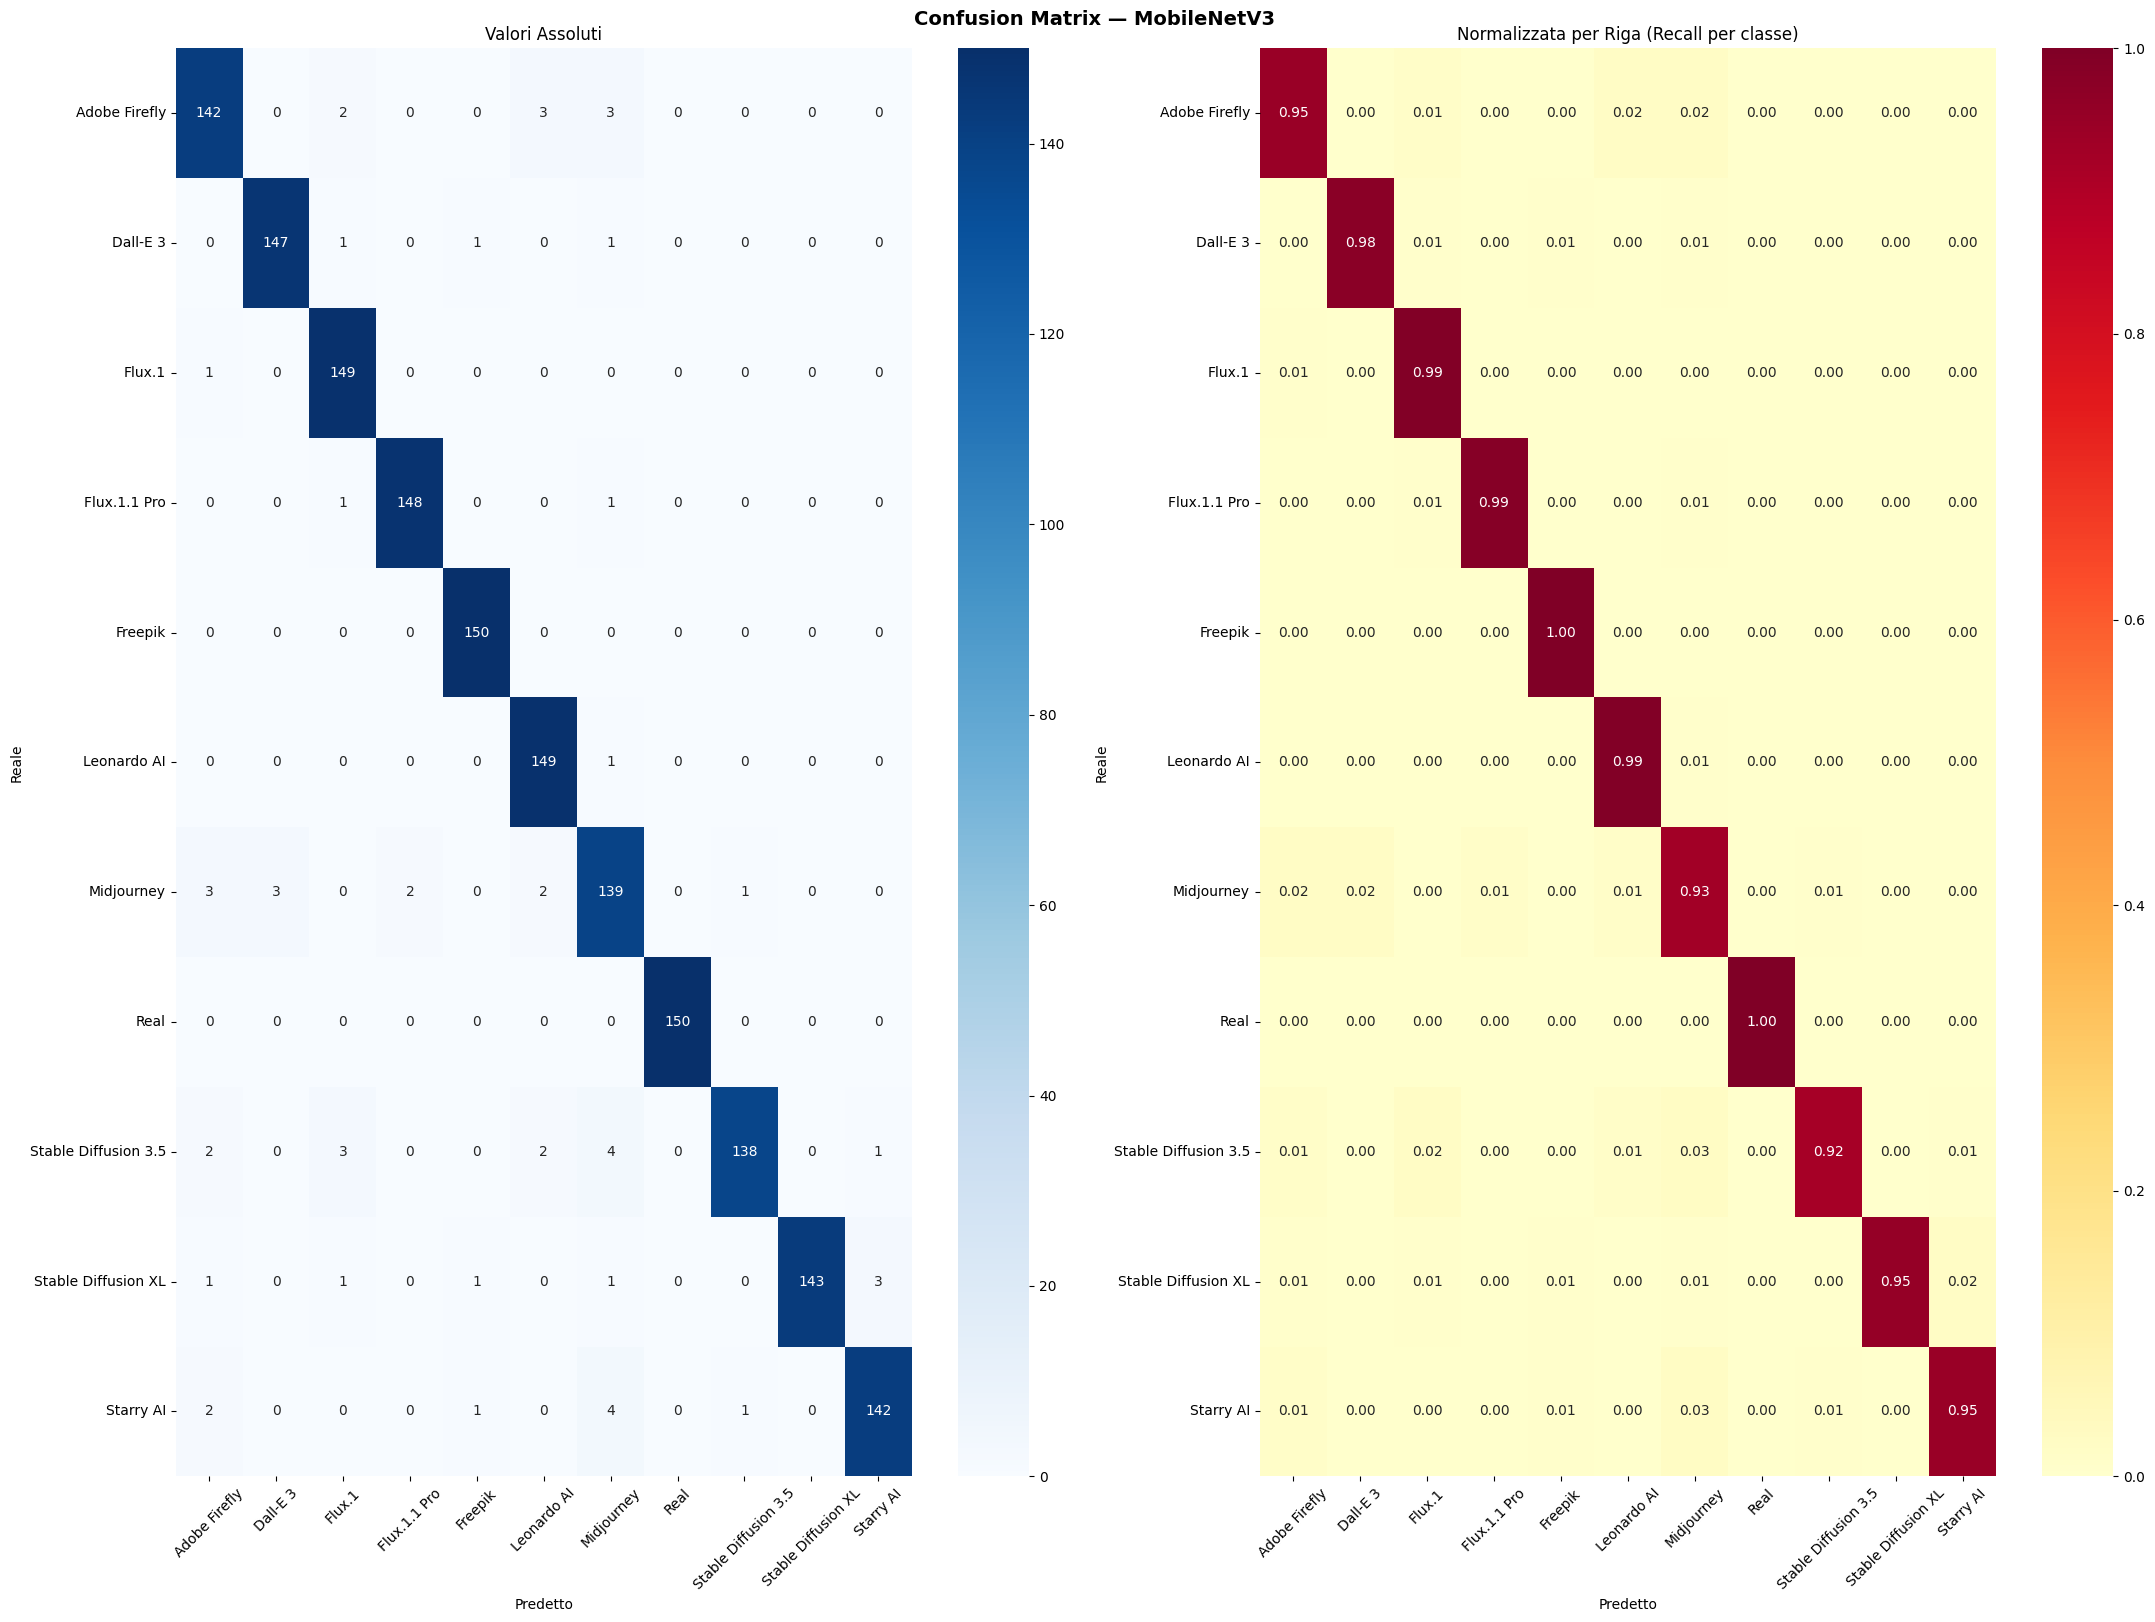


   Classification Report (MobileNetV3):
                      precision    recall  f1-score   support

       Adobe Firefly     0.9404    0.9467    0.9435       150
            Dall-E 3     0.9800    0.9800    0.9800       150
              Flux.1     0.9490    0.9933    0.9707       150
        Flux.1.1 Pro     0.9867    0.9867    0.9867       150
             Freepik     0.9804    1.0000    0.9901       150
         Leonardo AI     0.9551    0.9933    0.9739       150
          Midjourney     0.9026    0.9267    0.9145       150
                Real     1.0000    1.0000    1.0000       150
Stable Diffusion 3.5     0.9857    0.9200    0.9517       150
 Stable Diffusion XL     1.0000    0.9533    0.9761       150
           Starry AI     0.9726    0.9467    0.9595       150

            accuracy                         0.9679      1650
           macro avg     0.9684    0.9679    0.9679      1650
        weighted avg     0.9684    0.9679    0.9679      1650


─────────────────────────

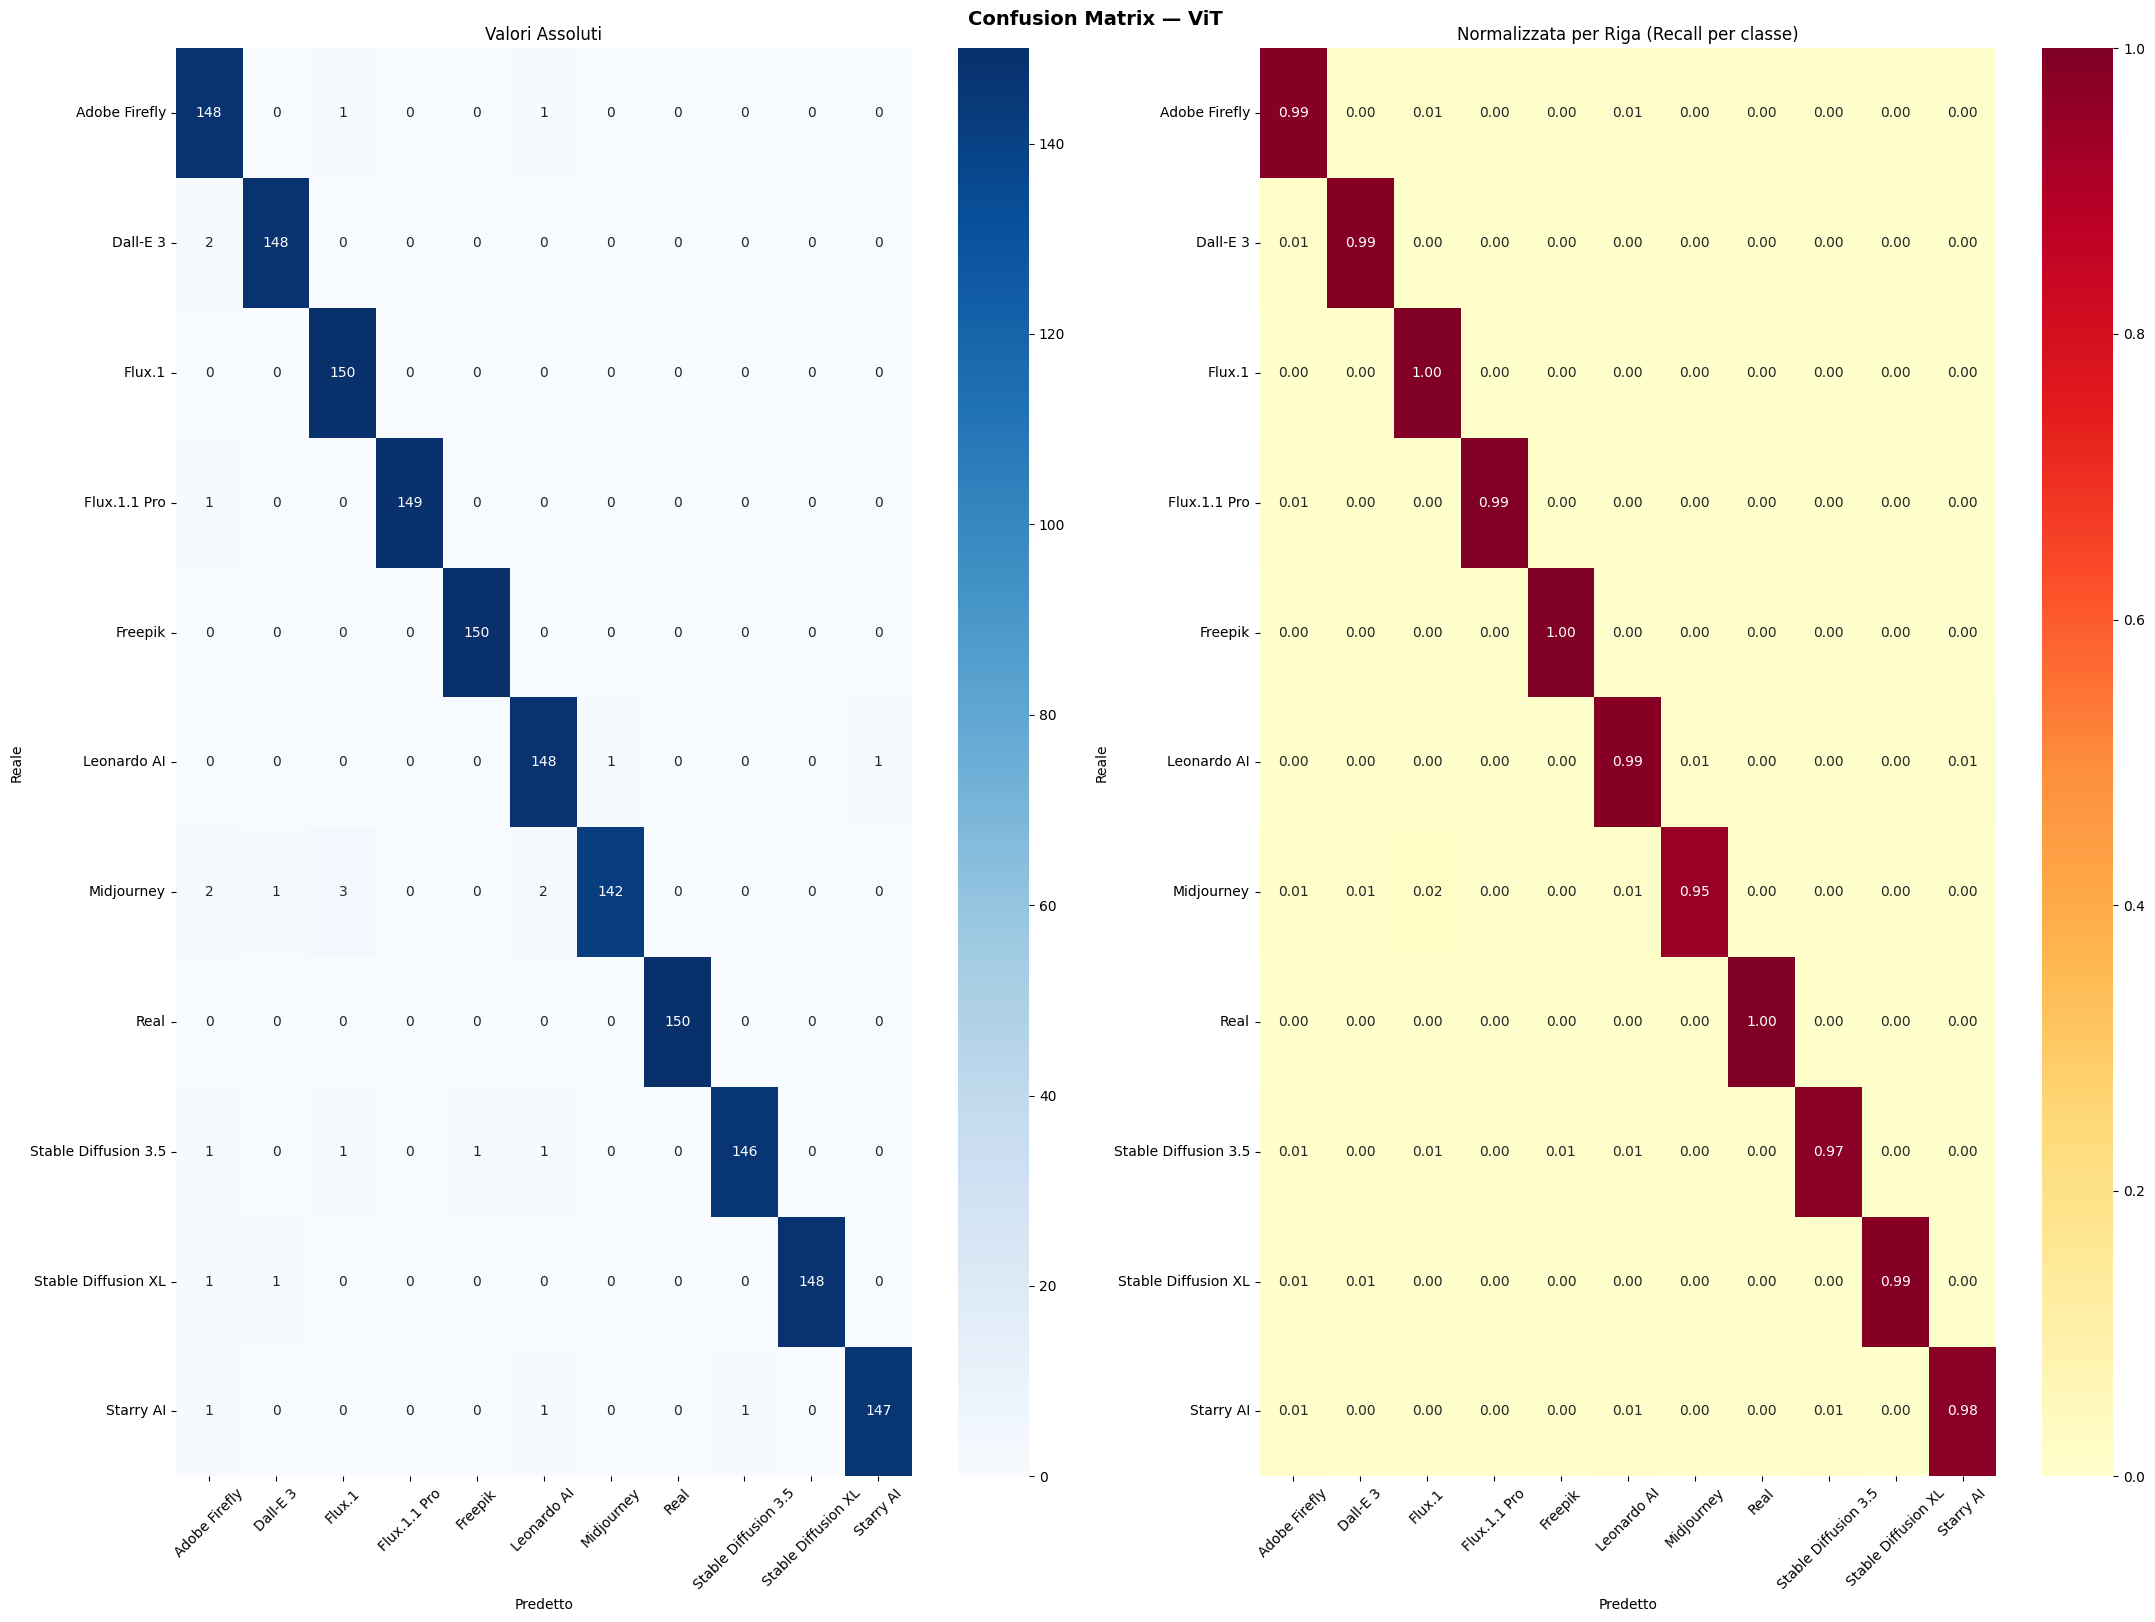


   Classification Report (ViT):
                      precision    recall  f1-score   support

       Adobe Firefly     0.9487    0.9867    0.9673       150
            Dall-E 3     0.9867    0.9867    0.9867       150
              Flux.1     0.9677    1.0000    0.9836       150
        Flux.1.1 Pro     1.0000    0.9933    0.9967       150
             Freepik     0.9934    1.0000    0.9967       150
         Leonardo AI     0.9673    0.9867    0.9769       150
          Midjourney     0.9930    0.9467    0.9693       150
                Real     1.0000    1.0000    1.0000       150
Stable Diffusion 3.5     0.9932    0.9733    0.9832       150
 Stable Diffusion XL     1.0000    0.9867    0.9933       150
           Starry AI     0.9932    0.9800    0.9866       150

            accuracy                         0.9855      1650
           macro avg     0.9858    0.9855    0.9855      1650
        weighted avg     0.9858    0.9855    0.9855      1650


✅ Valutazione completata per tutt

In [13]:
# Cella 9) Metroche & Confusion Matrix
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast():
            outputs = model(imgs)
        _, preds = outputs.max(1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)


def compute_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred) * 100,
        'precision': precision_score(y_true, y_pred, average='weighted',
                                     zero_division=0) * 100,
        'recall'   : recall_score(y_true, y_pred,    average='weighted',
                                  zero_division=0) * 100,
        'f1'       : f1_score(y_true, y_pred,        average='weighted',
                              zero_division=0) * 100,
    }


def plot_confusion_matrix(y_true, y_pred, class_names, nome_modello):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    n       = len(class_names)

    fig, axes = plt.subplots(1, 2, figsize=(max(14, n * 2), max(6, n * 1.5)))
    fig.suptitle(f'Confusion Matrix — {nome_modello}',
                 fontsize=14, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Valori Assoluti')
    axes[0].set_xlabel('Predetto')
    axes[0].set_ylabel('Reale')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalizzata per Riga (Recall per classe)')
    axes[1].set_xlabel('Predetto')
    axes[1].set_ylabel('Reale')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/cm_{nome_modello}.png', dpi=150, bbox_inches='tight')
    plt.show()


all_metrics = {}
all_preds   = {}

for nome in MODELLI:
    print(f'\n{"─"*55}')
    print(f'📊 Valutazione Test Set: {nome}')
    print(f'{"─"*55}')
    torch.cuda.empty_cache()

    is_inception = (nome == 'InceptionV3')
    ts_loader    = test_loader_inc if is_inception else test_loader

    # ── use_parallel=False: carica senza DataParallel ─────────────────────────
    model, _ = build_model(nome, len(CLASS_NAMES), use_parallel=False)
    model.load_state_dict(torch.load(all_best_paths[nome], map_location=device))
    model.eval()

    y_true, y_pred = get_predictions(model, ts_loader)
    metrics        = compute_metrics(y_true, y_pred)

    all_metrics[nome] = metrics
    all_preds[nome]   = (y_true, y_pred)

    print(f'   Accuracy  : {metrics["accuracy"]:.2f}%')
    print(f'   Precision : {metrics["precision"]:.2f}%')
    print(f'   Recall    : {metrics["recall"]:.2f}%')
    print(f'   F1-Score  : {metrics["f1"]:.2f}%')

    plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, nome)

    print(f'\n   Classification Report ({nome}):')
    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES, digits=4))

    del model
    torch.cuda.empty_cache()

print('\n✅ Valutazione completata per tutti i modelli!')

🎯 Calcolo soglie dinamiche sul Validation Set...

   Modello             Media       Std    Soglia
   ─────────────────────────────────────────────
   ResNet18          0.8609    0.1527    0.7845
   DenseNet121       0.8832    0.1086    0.8289
   VGG16             0.8836    0.1344    0.8164
   InceptionV3       0.8922    0.0931    0.8456
   MobileNetV3       0.8313    0.1640    0.7493
   ViT               0.8929    0.0764    0.8547


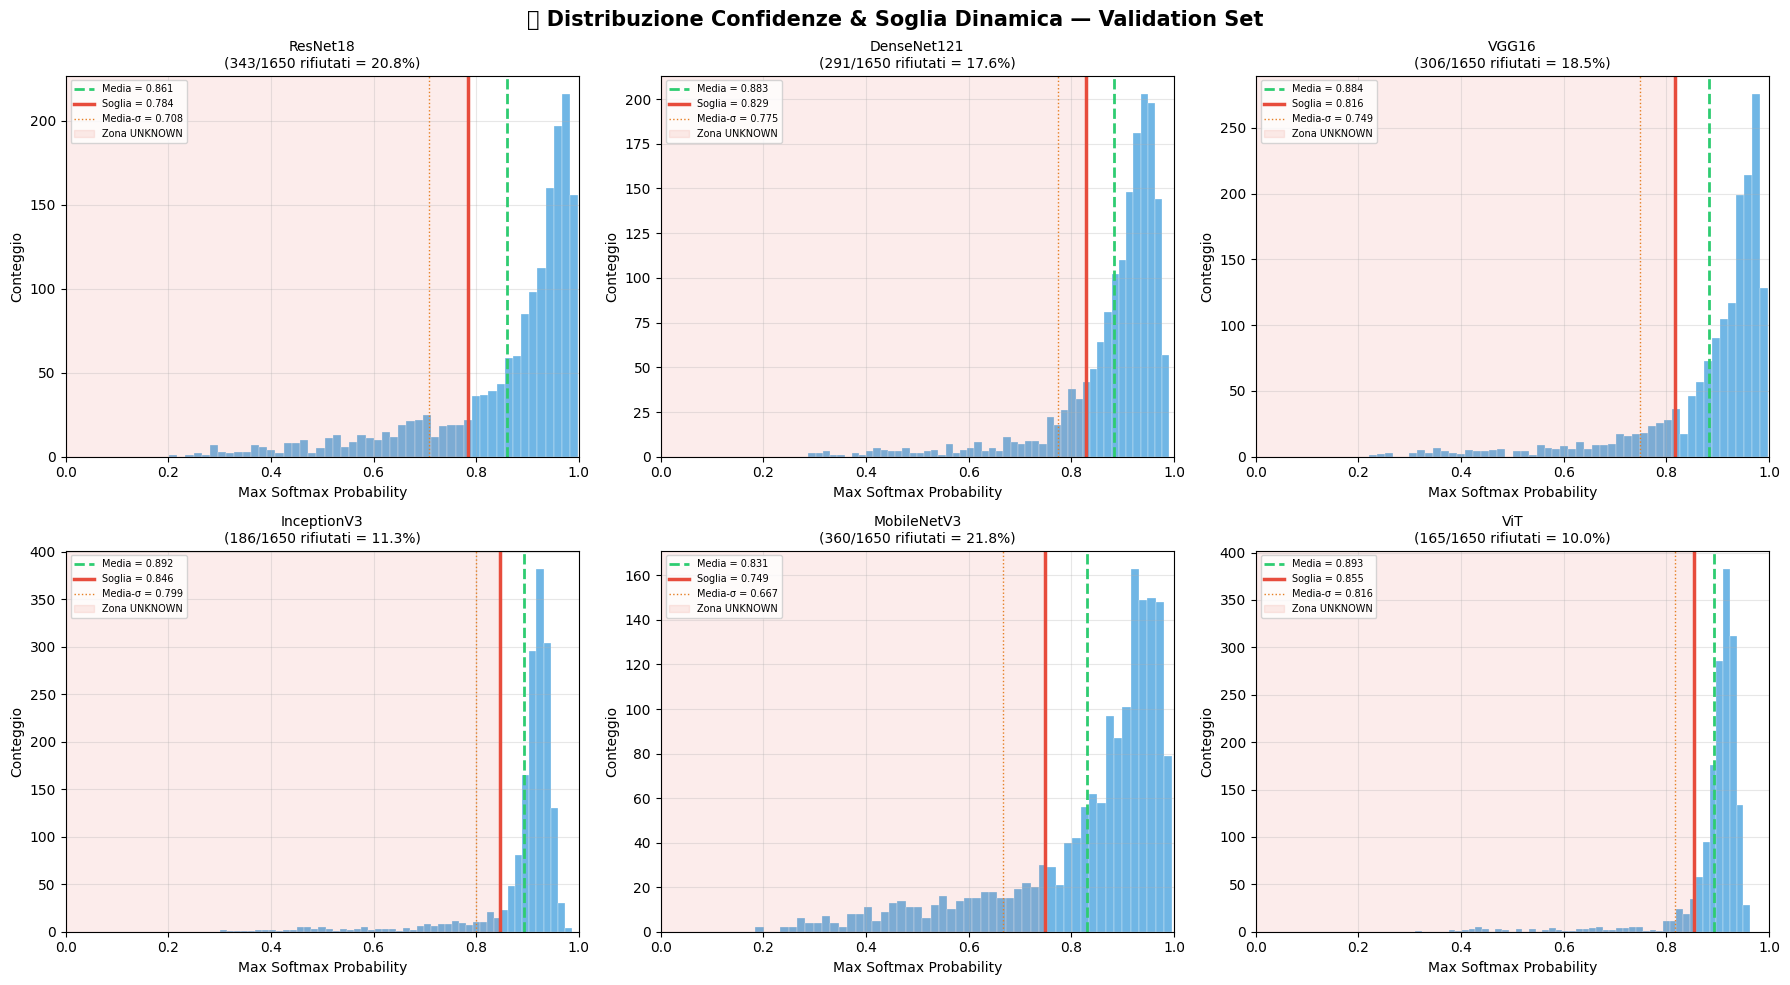


📋 Riepilogo soglie dinamiche:
             Media confidenza  Std confidenza  Soglia dinamica
ResNet18               0.8609          0.1527           0.7845
DenseNet121            0.8832          0.1086           0.8289
VGG16                  0.8836          0.1344           0.8164
InceptionV3            0.8922          0.0931           0.8456
MobileNetV3            0.8313          0.1640           0.7493
ViT                    0.8929          0.0764           0.8547

💾 Salvato in: /kaggle/working/deepfake_v2/soglie_dinamiche.csv


In [14]:
# Cella 9b) Soglia dinamica Validation Set
@torch.no_grad()
def calcola_soglia_dinamica(model, loader, k=K_STD):
    model.eval()
    confidenze = []
    for imgs, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast():
            outputs = model(imgs)
        probs        = F.softmax(outputs, dim=1)
        max_probs, _ = probs.max(dim=1)
        confidenze.extend(max_probs.cpu().numpy().tolist())

    confidenze = np.array(confidenze)
    media      = confidenze.mean()
    std        = confidenze.std()
    soglia     = media - k * std
    return soglia, media, std, confidenze


soglie_dinamiche = {}

print('🎯 Calcolo soglie dinamiche sul Validation Set...\n')
print(f'   {"Modello":<15}  {"Media":>8}  {"Std":>8}  {"Soglia":>8}')
print('   ' + '─' * 45)

for nome in MODELLI:
    is_inception = (nome == 'InceptionV3')
    vl_loader    = val_loader_inc if is_inception else val_loader

    # ── use_parallel=False: carica senza DataParallel ─────────────────────────
    model, _ = build_model(nome, len(CLASS_NAMES), use_parallel=False)
    model.load_state_dict(torch.load(all_best_paths[nome], map_location=device))

    soglia, media, std, conf_arr = calcola_soglia_dinamica(model, vl_loader)
    soglie_dinamiche[nome] = {
        'soglia': soglia, 'media': media, 'std': std, 'conf': conf_arr
    }

    print(f'   {nome:<15}  {media:>7.4f}   {std:>7.4f}   {soglia:>7.4f}')

    del model
    torch.cuda.empty_cache()

# ── Visualizzazione distribuzione confidenze ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🎯 Distribuzione Confidenze & Soglia Dinamica — Validation Set',
             fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, nome in enumerate(MODELLI):
    d      = soglie_dinamiche[nome]
    conf   = d['conf']
    soglia = d['soglia']
    media  = d['media']
    std    = d['std']
    ax     = axes_flat[i]

    ax.hist(conf, bins=50, color='#3498db', alpha=0.7,
            edgecolor='white', linewidth=0.3)
    ax.axvline(media,       color='#2ecc71', linewidth=2,
               linestyle='--', label=f'Media = {media:.3f}')
    ax.axvline(soglia,      color='#e74c3c', linewidth=2.5,
               linestyle='-',  label=f'Soglia = {soglia:.3f}')
    ax.axvline(media - std, color='#e67e22', linewidth=1,
               linestyle=':',  label=f'Media-σ = {media-std:.3f}')
    ax.axvspan(0, soglia, alpha=0.1, color='#e74c3c', label='Zona UNKNOWN')

    n_rejected = (conf < soglia).sum()
    pct        = 100 * n_rejected / len(conf)
    ax.set_title(f'{nome}\n({n_rejected}/{len(conf)} rifiutati = {pct:.1f}%)',
                 fontsize=10)
    ax.set_xlabel('Max Softmax Probability')
    ax.set_ylabel('Conteggio')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/soglie_dinamiche.png', dpi=150, bbox_inches='tight')
plt.show()

df_soglie = pd.DataFrame({
    nome: {
        'Media confidenza': round(d['media'],  4),
        'Std confidenza'  : round(d['std'],    4),
        'Soglia dinamica' : round(d['soglia'], 4),
    }
    for nome, d in soglie_dinamiche.items()
}).T
print('\n📋 Riepilogo soglie dinamiche:')
print(df_soglie.to_string())
df_soglie.to_csv(f'{BASE_DIR}/soglie_dinamiche.csv')
print(f'\n💾 Salvato in: {BASE_DIR}/soglie_dinamiche.csv')

🚨 Open-Set Detection sul Test Set...

   Modello            Soglia       UNKNOWN    Acc Closed   Acc Known
   ─────────────────────────────────────────────────────────────────
   ResNet18          0.7845    376 (22.8%)       97.33%     99.84%
   DenseNet121       0.8289    331 (20.1%)       97.76%     99.85%
   VGG16             0.8164    310 (18.8%)       98.48%    100.00%
   InceptionV3       0.8456    173 (10.5%)       97.70%     99.53%
   MobileNetV3       0.7493    384 (23.3%)       96.79%     99.68%
   ViT               0.8547    188 (11.4%)       98.55%     99.93%


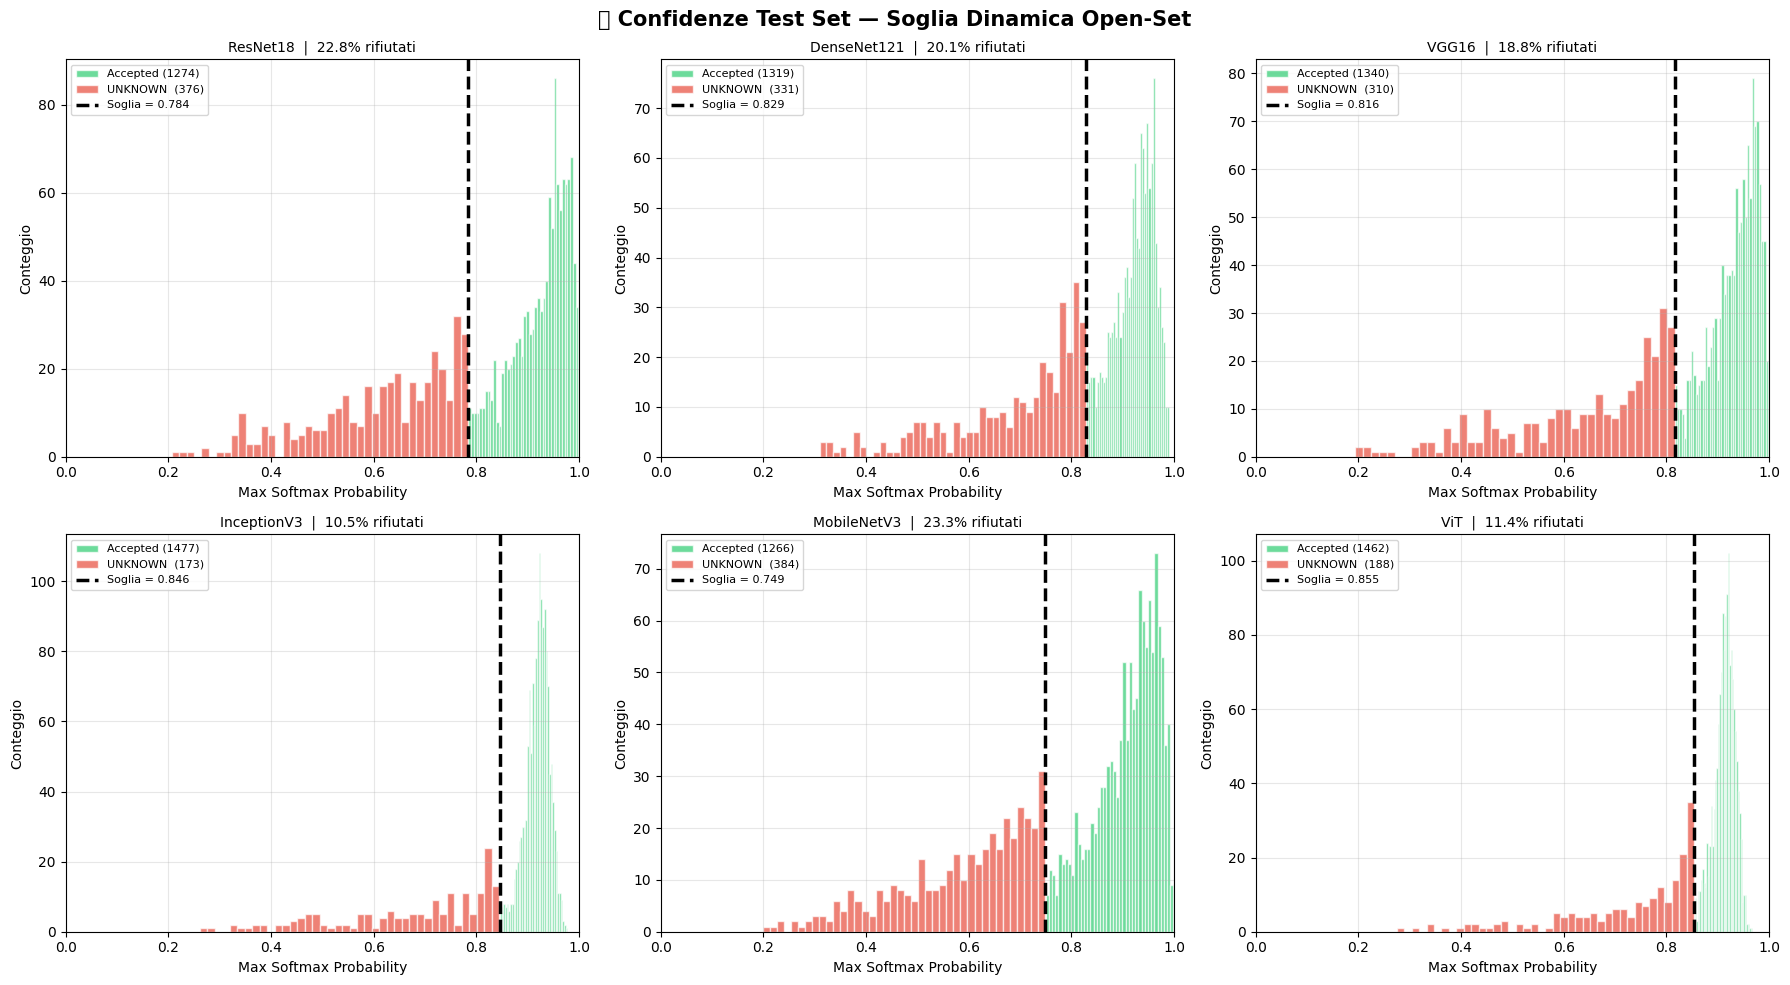


📋 Riepilogo Open-Set Detection:
             Soglia dinamica  UNKNOWN (#)  UNKNOWN (%)  Acc Closed-Set (%)  Acc su Known (%)
ResNet18              0.7845        376.0        22.79               97.33             99.84
DenseNet121           0.8289        331.0        20.06               97.76             99.85
VGG16                 0.8164        310.0        18.79               98.48            100.00
InceptionV3           0.8456        173.0        10.48               97.70             99.53
MobileNetV3           0.7493        384.0        23.27               96.79             99.68
ViT                   0.8547        188.0        11.39               98.55             99.93

💾 Salvato in: /kaggle/working/deepfake_v2/openset_results.csv


In [15]:
s


  🏆  CONFRONTO FINALE — Metriche sul Test Set (ordinato per F1)
             Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Modello                                                           
ViT                 98.55          98.58       98.55         98.55
VGG16               98.48          98.50       98.48         98.48
DenseNet121         97.76          97.81       97.76         97.76
InceptionV3         97.70          97.80       97.70         97.71
ResNet18            97.33          97.36       97.33         97.34
MobileNetV3         96.79          96.84       96.79         96.79

  🥇 Miglior modello (F1)  : ViT
  🥇 Miglior modello (Acc) : ViT


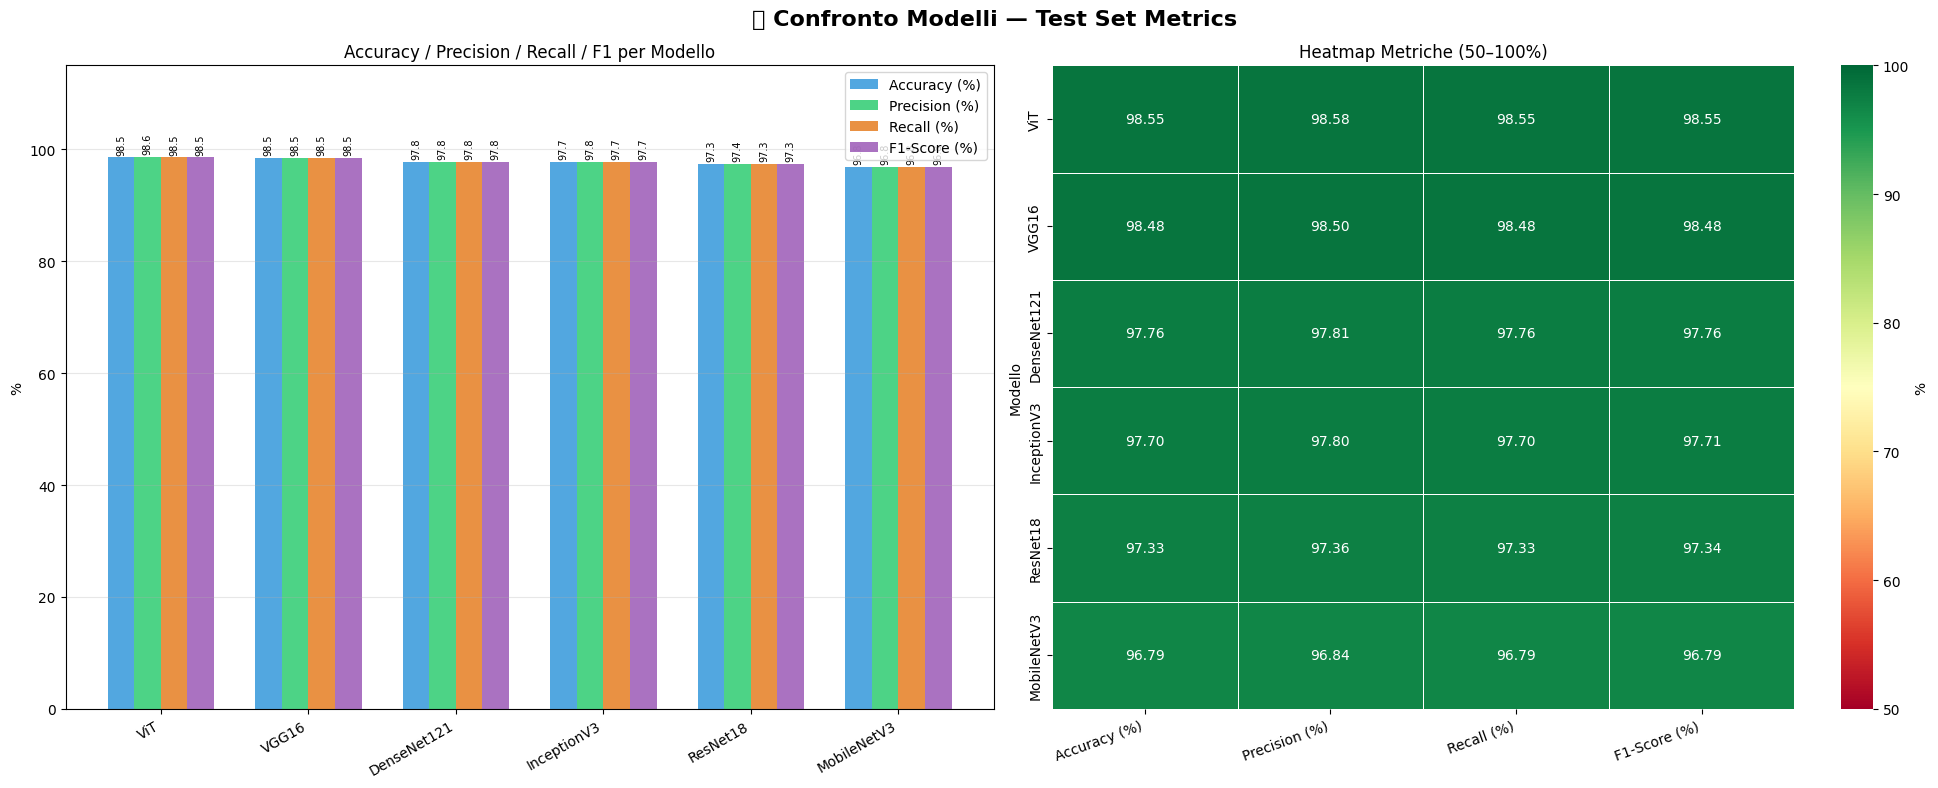


📊 F1-Score per classe...


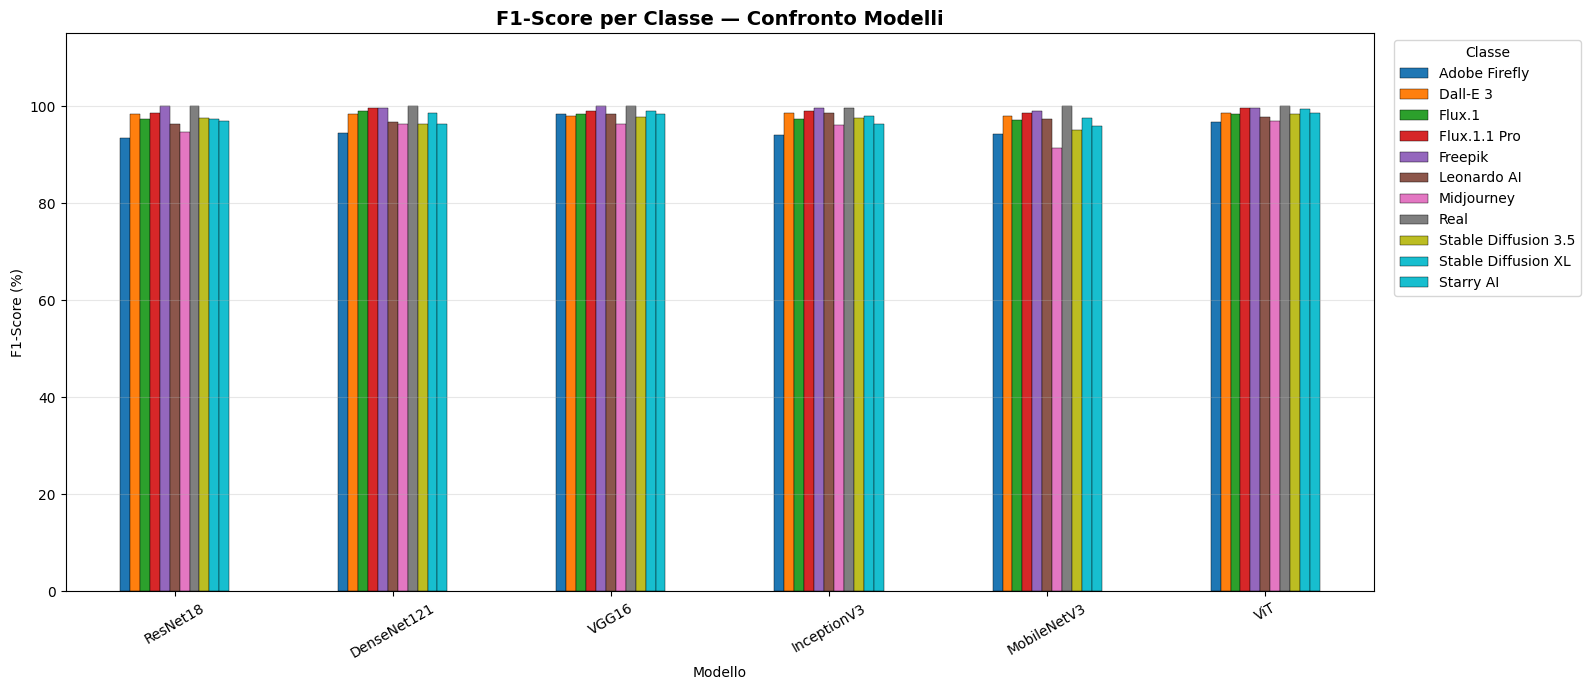


💾 Metriche salvate in: /kaggle/working/deepfake_v2/metriche_finali.csv

  📝 ANALISI AUTOMATICA DEI RISULTATI

  🥇 MIGLIOR modello (F1): ViT
     F1=98.55%  Acc=98.55%  Prec=98.58%  Rec=98.55%

  🔻 MODELLO più in difficoltà (F1): MobileNetV3
     F1=96.79%

  📌 NOTE INTERPRETATIVE:
  - F1-Score weighted è la metrica più affidabile su dataset sbilanciati.
  - Precision alta → pochi falsi positivi (Fake classificati come Real).
  - Recall alta    → pochi falsi negativi (Real classificati come Fake).
  - ViT richiede più dati; con ~700 img/classe i CNN generalizzano meglio.
  - CelebA-HQ (256x256 uniforme) garantisce una classe Real visivamente
    coerente, migliorando la separabilità dagli artefatti GAN/DM.
  - La soglia dinamica (media - 0.5*std) si adatta al comportamento
    di ogni modello, evitando valori fissi arbitrari.

🎉 Pipeline completata! Tutti i file sono in: /kaggle/working/deepfake_v2


In [16]:
# Cella 10) Confronto modelli
# ── Tabella riassuntiva ───────────────────────────────────────────────────────
df_metrics = pd.DataFrame(all_metrics).T
df_metrics.index.name = 'Modello'
df_metrics = df_metrics.rename(columns={
    'accuracy' : 'Accuracy (%)',
    'precision': 'Precision (%)',
    'recall'   : 'Recall (%)',
    'f1'       : 'F1-Score (%)'
})
df_metrics = df_metrics.sort_values('F1-Score (%)', ascending=False)

print('\n' + '='*70)
print('  🏆  CONFRONTO FINALE — Metriche sul Test Set (ordinato per F1)')
print('='*70)
print(df_metrics.round(2).to_string())
print(f'\n  🥇 Miglior modello (F1)  : {df_metrics["F1-Score (%)"].idxmax()}')
print(f'  🥇 Miglior modello (Acc) : {df_metrics["Accuracy (%)"].idxmax()}')

# ── Barre raggruppate + heatmap ───────────────────────────────────────────────
metrics_cols    = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
colori_metriche = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('🏆 Confronto Modelli — Test Set Metrics',
             fontsize=16, fontweight='bold')

x     = np.arange(len(df_metrics))
width = 0.18
for i, (col, colore) in enumerate(zip(metrics_cols, colori_metriche)):
    axes[0].bar(x + i * width, df_metrics[col], width,
                label=col, color=colore, alpha=0.85)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(df_metrics.index, rotation=30, ha='right')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 115)
axes[0].set_title('Accuracy / Precision / Recall / F1 per Modello')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=7, padding=2, rotation=90)

sns.heatmap(df_metrics[metrics_cols], annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=50, vmax=100, ax=axes[1],
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '%'})
axes[1].set_title('Heatmap Metriche (50–100%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/confronto_modelli.png', dpi=150, bbox_inches='tight')
plt.show()

# ── F1 per classe per ogni modello ────────────────────────────────────────────
print('\n📊 F1-Score per classe...')
f1_per_classe = {}
for nome in MODELLI:
    y_true, y_pred      = all_preds[nome]
    f1_per_classe[nome] = f1_score(y_true, y_pred,
                                   average=None, zero_division=0) * 100

df_f1_cls = pd.DataFrame(f1_per_classe, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(16, 7))
df_f1_cls.T.plot(kind='bar', ax=ax, colormap='tab10',
                 edgecolor='black', linewidth=0.3)
ax.set_title('F1-Score per Classe — Confronto Modelli',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Modello')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 115)
ax.legend(title='Classe', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/f1_per_classe.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Salva CSV ─────────────────────────────────────────────────────────────────
df_metrics.to_csv(f'{BASE_DIR}/metriche_finali.csv')
print(f'\n💾 Metriche salvate in: {BASE_DIR}/metriche_finali.csv')

# ── Analisi automatica ────────────────────────────────────────────────────────
best_f1  = df_metrics['F1-Score (%)'].idxmax()
worst_f1 = df_metrics['F1-Score (%)'].idxmin()

print('\n' + '='*70)
print('  📝 ANALISI AUTOMATICA DEI RISULTATI')
print('='*70)
print(f'\n  🥇 MIGLIOR modello (F1): {best_f1}')
print(f'     F1={df_metrics.loc[best_f1, "F1-Score (%)"]:.2f}%  '
      f'Acc={df_metrics.loc[best_f1, "Accuracy (%)"]:.2f}%  '
      f'Prec={df_metrics.loc[best_f1, "Precision (%)"]:.2f}%  '
      f'Rec={df_metrics.loc[best_f1, "Recall (%)"]:.2f}%')
print(f'\n  🔻 MODELLO più in difficoltà (F1): {worst_f1}')
print(f'     F1={df_metrics.loc[worst_f1, "F1-Score (%)"]:.2f}%')

print("""
  📌 NOTE INTERPRETATIVE:
  - F1-Score weighted è la metrica più affidabile su dataset sbilanciati.
  - Precision alta → pochi falsi positivi (Fake classificati come Real).
  - Recall alta    → pochi falsi negativi (Real classificati come Fake).
  - ViT richiede più dati; con ~700 img/classe i CNN generalizzano meglio.
  - CelebA-HQ (256x256 uniforme) garantisce una classe Real visivamente
    coerente, migliorando la separabilità dagli artefatti GAN/DM.
  - La soglia dinamica (media - 0.5*std) si adatta al comportamento
    di ogni modello, evitando valori fissi arbitrari.
""")

print(f'🎉 Pipeline completata! Tutti i file sono in: {BASE_DIR}')